# Weak Lensing Statistics Visualization

This notebook visualizes all statistics computed from the `compute_all_stats.py` pipeline for weak lensing convergence maps.

**Statistics included:**
1. **Power Spectrum** $P(k)$ - 2D density field
2. **Angular Power Spectrum** $C_\ell$ - convergence maps
3. **Peak Counts** - local maxima distribution
4. **Minima Counts** - local minima distribution  
5. **PDF** - pixel value distribution
6. **Minkowski Functionals** - $V_0$, $V_1$, $V_2$
7. **Wavelet Scattering Transform** - $S_0$, $S_1$
8. **Bispectrum** - equilateral, squeezed, folded, isosceles configurations

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

# Set up plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14

# Paths
STATS_BASE = Path('/mnt/home/mlee1/ceph/hydro_replace_stats')

# Choose model to visualize
MODEL = 'hydro'  # or 'hydro' or a replace model
stats_file = STATS_BASE / MODEL / 'stats.h5'

print(f"Loading statistics from: {stats_file}")
print(f"File exists: {stats_file.exists()}")

Loading statistics from: /mnt/home/mlee1/ceph/hydro_replace_stats/hydro/stats.h5
File exists: True


In [2]:
# Load all statistics
with h5py.File(stats_file, 'r') as f:
    print("Available datasets:")
    for key in f.keys():
        if isinstance(f[key], h5py.Dataset):
            print(f"  {key}: {f[key].shape}")
    
    print("\nAttributes:")
    for attr in f.attrs:
        print(f"  {attr}: {f.attrs[attr]}")
    
    # Load datasets
    data = {}
    for key in f.keys():
        if isinstance(f[key], h5py.Dataset):
            data[key] = f[key][:]
    
    # Load attributes
    attrs = dict(f.attrs)

# Extract useful info
source_z = attrs.get('source_redshifts', [0.5, 1.0, 2.0, 2.5])
z_labels = [f'z={z:.2f}' for z in source_z]
print(f"\nSource redshifts: {source_z}")

Available datasets:
  Cl: (2000, 4, 724)
  Pk: (20, 40, 2896)
  S0: (2000, 4, 3)
  S1: (2000, 4, 5, 3)
  V0: (2000, 4, 51)
  V1: (2000, 4, 51)
  V2: (2000, 4, 51)
  bispec_ell: (19,)
  bispec_equilateral: (2000, 4, 19)
  bispec_folded: (2000, 4, 19)
  bispec_isosceles: (2000, 4, 19)
  bispec_squeezed: (2000, 4, 19)
  ell_bins: (724,)
  k_bins: (2896,)
  mass: (20, 40)
  mf_thresholds: (51,)
  minima: (2000, 4, 50)
  pdf: (2000, 4, 50)
  peaks: (2000, 4, 50)
  sn_bin_edges: (51,)
  wst_moments: (3,)
  wst_scales: (5,)

Attributes:
  BOX_SIZE: 205.0
  FOV_DEG: 5.0
  N_LP: 20
  N_RUNS: 100
  WST_J: 5
  WST_Q: 1
  bispec_configs: ['equilateral' 'squeezed' 'folded' 'isosceles']
  computed_Cl: True
  computed_bispectrum: True
  computed_density: True
  computed_minima: True
  computed_minkowski: True
  computed_pdf: True
  computed_peaks: True
  computed_wst: True
  kappa_targets: [13 23 36 40]
  model: hydro
  smoothing_arcmin: 0.0
  snapshot_order: [96 90 85 80 76 71 67 63 59 56 52 49 46 4


Source redshifts: [0.506 1.034 2.094 2.568]


---
## 1. Power Spectrum $P(k)$

The 2D matter power spectrum measures the amplitude of density fluctuations as a function of wavenumber $k$:

$$P(k) = \langle |\tilde{\delta}(\mathbf{k})|^2 \rangle$$

where $\tilde{\delta}(\mathbf{k})$ is the Fourier transform of the overdensity field:

$$\delta(\mathbf{x}) = \frac{\rho(\mathbf{x}) - \bar{\rho}}{\bar{\rho}}$$

The power spectrum is computed from lensplanes (projected density fields) and averaged over azimuthal angles in $k$-space.

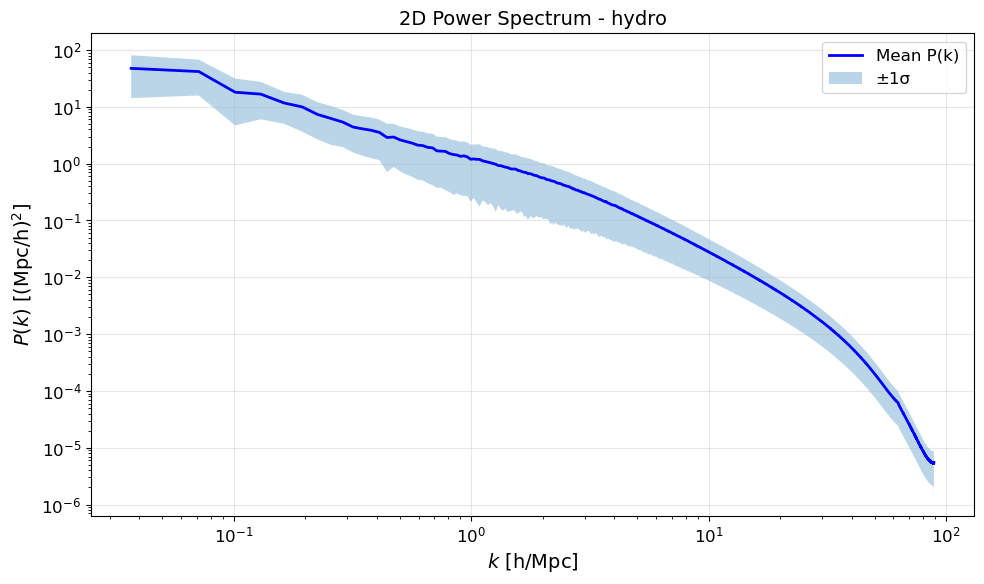

P(k) shape: (20, 40, 2896) (N_LP, N_planes, N_k)


In [3]:
# Plot P(k) from lensplanes
if 'Pk' in data and 'k_bins' in data:
    Pk = data['Pk']  # Shape: (N_LP, N_planes, N_k)
    k = data['k_bins']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Average over all LP orientations and a few planes
    Pk_mean = np.nanmean(Pk, axis=(0, 1))
    Pk_std = np.nanstd(Pk, axis=(0, 1))
    
    ax.loglog(k, Pk_mean, 'b-', lw=2, label='Mean P(k)')
    ax.fill_between(k, Pk_mean - Pk_std, Pk_mean + Pk_std, alpha=0.3, label='±1σ')
    
    ax.set_xlabel(r'$k$ [h/Mpc]')
    ax.set_ylabel(r'$P(k)$ [(Mpc/h)$^2$]')
    ax.set_title(f'2D Power Spectrum - {MODEL}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"P(k) shape: {Pk.shape} (N_LP, N_planes, N_k)")
else:
    print("P(k) data not available")

---
## 2. Angular Power Spectrum $C_\ell$

The angular power spectrum describes the variance of the convergence field as a function of multipole $\ell$:

$$C_\ell = \langle |\tilde{\kappa}_{\ell m}|^2 \rangle$$

For a flat-sky approximation with field of view $\theta$:

$$\ell \approx \frac{2\pi k}{\theta}$$

where $k$ is the 2D wavenumber in cycles/radian. $C_\ell$ is related to the matter power spectrum via the Limber approximation:

$$C_\ell = \int_0^{\chi_s} d\chi \, \frac{W^2(\chi)}{\chi^2} P\left(\frac{\ell}{\chi}, z(\chi)\right)$$

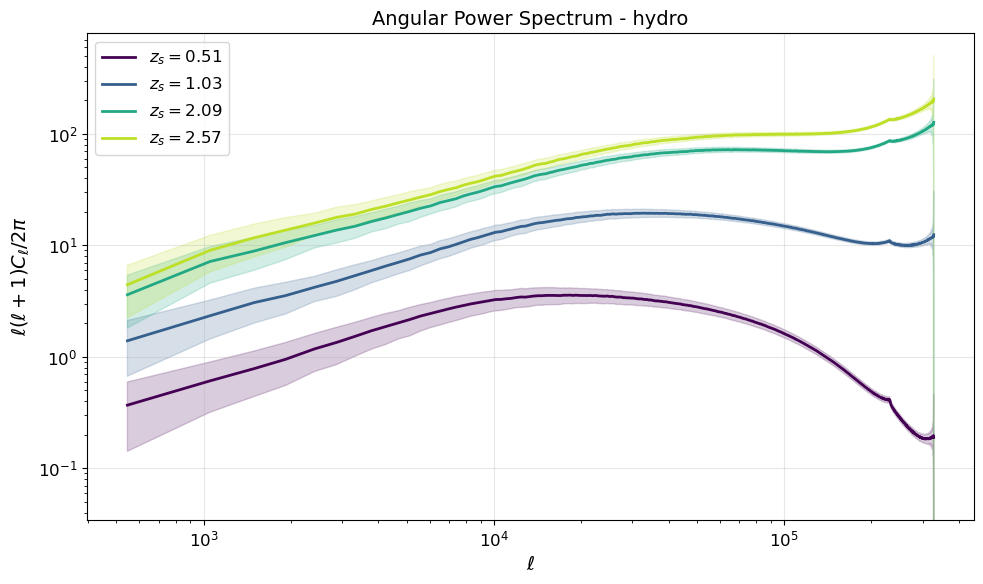

C_ℓ shape: (2000, 4, 724) (N_real, N_z, N_ell)


In [4]:
# Plot C_ell
if 'Cl' in data and 'ell_bins' in data:
    Cl = data['Cl']  # Shape: (N_real, N_z, N_ell)
    ell = data['ell_bins']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        Cl_mean = np.nanmean(Cl[:, z_idx, :], axis=0)
        Cl_std = np.nanstd(Cl[:, z_idx, :], axis=0)
        
        ax.loglog(ell, ell * (ell + 1) * Cl_mean / (2 * np.pi), 
                  color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(ell, 
                        ell * (ell + 1) * (Cl_mean - Cl_std) / (2 * np.pi),
                        ell * (ell + 1) * (Cl_mean + Cl_std) / (2 * np.pi),
                        color=color, alpha=0.2)
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\ell(\ell+1)C_\ell / 2\pi$')
    ax.set_title(f'Angular Power Spectrum - {MODEL}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"C_ℓ shape: {Cl.shape} (N_real, N_z, N_ell)")
else:
    print("C_ℓ data not available")

---
## 3. Peak Counts

Peak counts measure the number density of local maxima (peaks) in the smoothed convergence field as a function of signal-to-noise ratio $\nu$:

$$n_\text{peak}(\nu) = \frac{dN_\text{peak}}{d\nu}$$

where the signal-to-noise is defined as:

$$\nu = \frac{\kappa}{\sigma_0}$$

and $\sigma_0$ is the RMS of the DMO field (used as normalization). Peaks are detected as pixels where:

$$\kappa(x, y) > \kappa(x', y') \quad \forall \, |x'-x| \leq 1, |y'-y| \leq 1$$

High-$\nu$ peaks correspond to massive halos; low/negative $\nu$ peaks trace voids and noise.

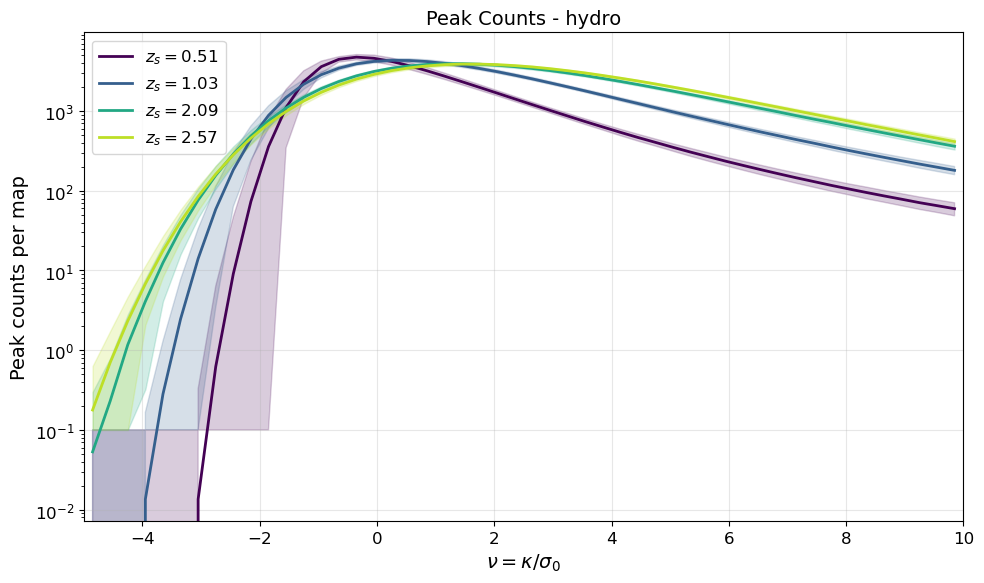

Peak counts shape: (2000, 4, 50) (N_real, N_z, N_bins)


In [5]:
# Plot Peak Counts
if 'peaks' in data and 'sn_bin_edges' in data:
    peaks = data['peaks']  # Shape: (N_real, N_z, N_bins)
    sn_edges = data['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        peaks_mean = np.nanmean(peaks[:, z_idx, :], axis=0)
        peaks_std = np.nanstd(peaks[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, peaks_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers, 
                        np.maximum(peaks_mean - peaks_std, 0.1),
                        peaks_mean + peaks_std,
                        color=color, alpha=0.2)
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Peak counts per map')
    ax.set_title(f'Peak Counts - {MODEL}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 10)
    plt.tight_layout()
    plt.show()
    
    print(f"Peak counts shape: {peaks.shape} (N_real, N_z, N_bins)")
else:
    print("Peak counts data not available")

---
## 4. Minima Counts

Minima counts are analogous to peak counts but measure local minima (troughs):

$$n_\text{min}(\nu) = \frac{dN_\text{min}}{d\nu}$$

Minima are detected as pixels where:

$$\kappa(x, y) < \kappa(x', y') \quad \forall \, |x'-x| \leq 1, |y'-y| \leq 1$$

Minima at negative $\nu$ correspond to underdense regions (voids), which are also affected by baryonic physics through processes like AGN feedback that can push gas out of halos.

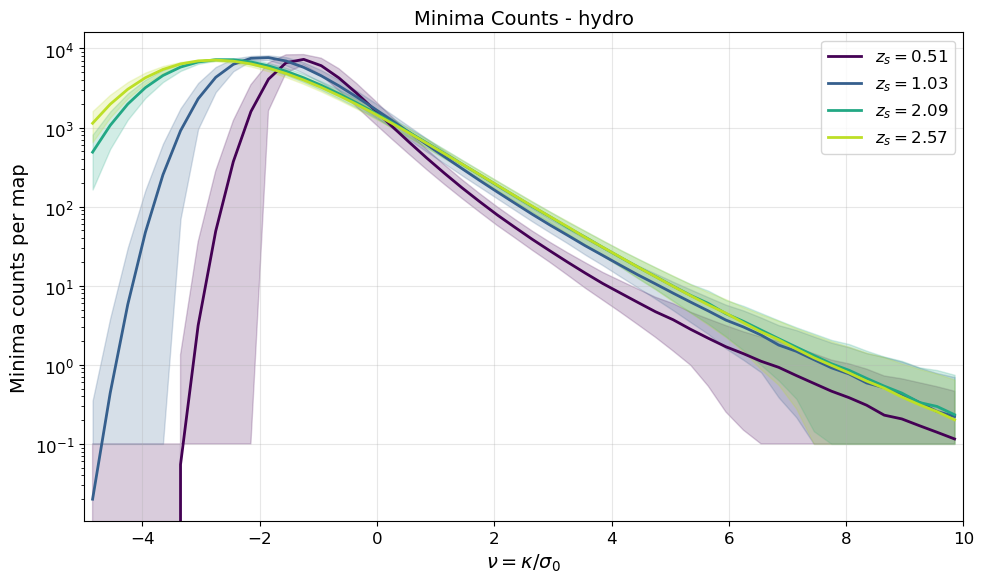

Minima counts shape: (2000, 4, 50) (N_real, N_z, N_bins)


In [6]:
# Plot Minima Counts
if 'minima' in data and 'sn_bin_edges' in data:
    minima = data['minima']  # Shape: (N_real, N_z, N_bins)
    sn_edges = data['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        minima_mean = np.nanmean(minima[:, z_idx, :], axis=0)
        minima_std = np.nanstd(minima[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, minima_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers,
                        np.maximum(minima_mean - minima_std, 0.1),
                        minima_mean + minima_std,
                        color=color, alpha=0.2)
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Minima counts per map')
    ax.set_title(f'Minima Counts - {MODEL}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 10)
    plt.tight_layout()
    plt.show()
    
    print(f"Minima counts shape: {minima.shape} (N_real, N_z, N_bins)")
else:
    print("Minima counts data not available")

---
## 5. Pixel PDF (Probability Distribution Function)

The one-point PDF measures the probability distribution of convergence values:

$$P(\kappa) = \frac{1}{N_\text{pix}} \frac{dN}{d\kappa}$$

For a Gaussian random field, this would be:

$$P(\nu) = \frac{1}{\sqrt{2\pi}} e^{-\nu^2/2}$$

Deviations from Gaussianity (skewness, kurtosis) encode information about non-linear structure formation and baryonic effects.

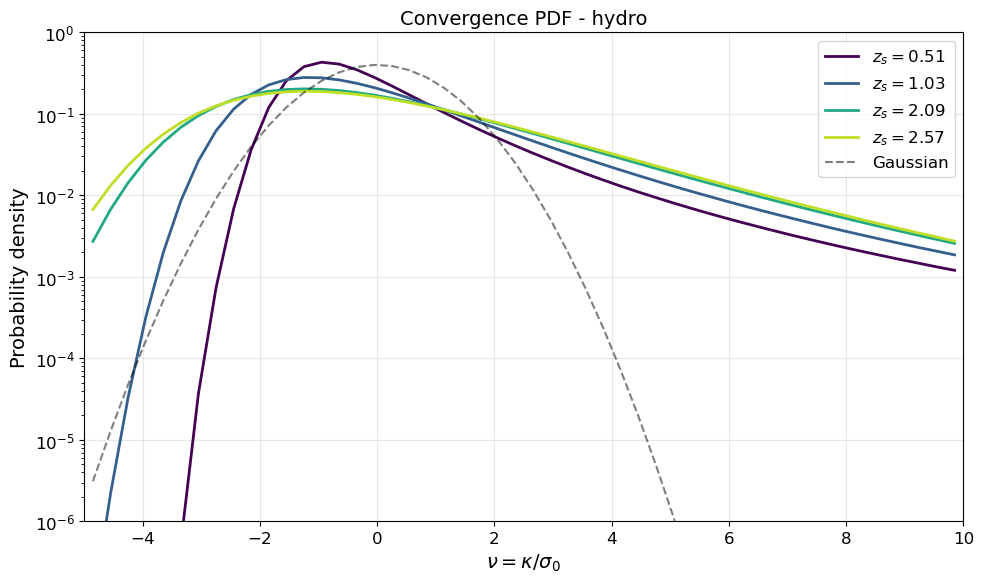

PDF shape: (2000, 4, 50) (N_real, N_z, N_bins)


In [7]:
# Plot PDF
if 'pdf' in data and 'sn_bin_edges' in data:
    pdf = data['pdf']  # Shape: (N_real, N_z, N_bins)
    sn_edges = data['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    bin_width = sn_edges[1] - sn_edges[0]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Normalize to get probability density
        pdf_mean = np.nanmean(pdf[:, z_idx, :], axis=0)
        pdf_norm = pdf_mean / (np.sum(pdf_mean) * bin_width)
        
        ax.semilogy(sn_centers, pdf_norm, color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    # Add Gaussian reference
    gaussian = np.exp(-sn_centers**2 / 2) / np.sqrt(2 * np.pi)
    ax.semilogy(sn_centers, gaussian, 'k--', lw=1.5, alpha=0.5, label='Gaussian')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Probability density')
    ax.set_title(f'Convergence PDF - {MODEL}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 10)
    ax.set_ylim(1e-6, 1)
    plt.tight_layout()
    plt.show()
    
    print(f"PDF shape: {pdf.shape} (N_real, N_z, N_bins)")
else:
    print("PDF data not available")

---
## 6. Minkowski Functionals

Minkowski functionals (MFs) characterize the morphology of excursion sets $\mathcal{E}_\nu = \{x : \kappa(x) \geq \nu\sigma_0\}$. In 2D, there are three MFs:

**$V_0$ (Area Fraction):** Fraction of pixels above threshold
$$V_0(\nu) = \frac{1}{A} \int_{\mathcal{E}_\nu} d^2x$$

**$V_1$ (Perimeter):** Boundary length of excursion set, normalized
$$V_1(\nu) = \frac{1}{4A} \oint_{\partial\mathcal{E}_\nu} dl$$

**$V_2$ (Euler Characteristic):** Topology measure = #connected regions - #holes
$$V_2(\nu) = \frac{1}{2\pi A} \oint_{\partial\mathcal{E}_\nu} \kappa_g \, dl$$

where $\kappa_g$ is the geodesic curvature of the boundary. For a Gaussian field, MFs have analytic predictions.

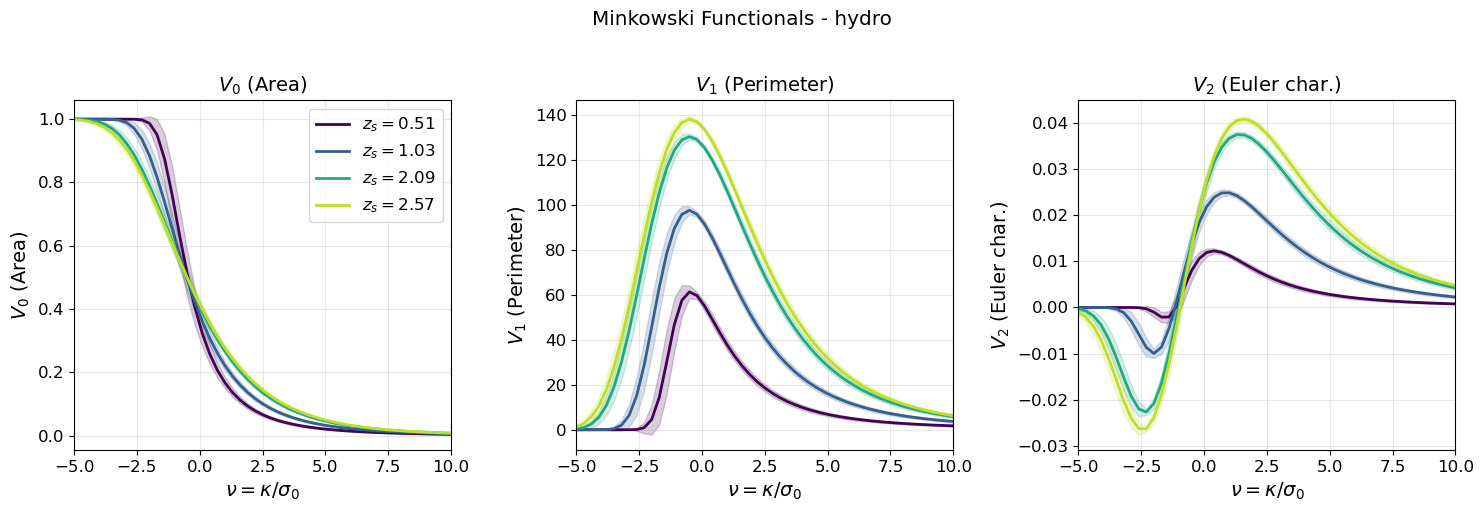

Minkowski functionals shape: (2000, 4, 51) (N_real, N_z, N_thresh)


In [8]:
# Plot Minkowski Functionals
if all(k in data for k in ['V0', 'V1', 'V2', 'mf_thresholds']):
    V0 = data['V0']  # Shape: (N_real, N_z, N_thresh)
    V1 = data['V1']
    V2 = data['V2']
    nu = data['mf_thresholds']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    MFs = [V0, V1, V2]
    titles = [r'$V_0$ (Area)', r'$V_1$ (Perimeter)', r'$V_2$ (Euler char.)']
    
    for ax, MF, title in zip(axes, MFs, titles):
        for z_idx, (z, color) in enumerate(zip(source_z, colors)):
            MF_mean = np.nanmean(MF[:, z_idx, :], axis=0)
            MF_std = np.nanstd(MF[:, z_idx, :], axis=0)
            
            ax.plot(nu, MF_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
            ax.fill_between(nu, MF_mean - MF_std, MF_mean + MF_std, color=color, alpha=0.2)
        
        ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-5, 10)
    
    axes[0].legend(loc='upper right')
    fig.suptitle(f'Minkowski Functionals - {MODEL}', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"Minkowski functionals shape: {V0.shape} (N_real, N_z, N_thresh)")
else:
    print("Minkowski functionals data not available")

---
## 7. Wavelet Scattering Transform (WST)

The WST provides multi-scale, non-Gaussian statistics by iteratively applying wavelet transforms and taking moduli. For a field $\kappa$:

**$S_0$ (Zeroth order):** Moments of the absolute field
$$S_0(p) = \langle |\kappa|^p \rangle$$

**$S_1$ (First order):** Moments of wavelet-filtered field at scale $j$
$$S_1(j, p) = \langle |\kappa \ast \psi_j|^p \rangle$$

where $\psi_j$ are wavelets at scale $2^j$, and $p \in \{0.5, 1, 2\}$ are moment orders.

The wavelets are bump-steerable wavelets (Lanusse+2012) with cutoff frequencies $k_c \cdot 2^{-j}$. WST coefficients capture non-Gaussian information beyond the power spectrum.

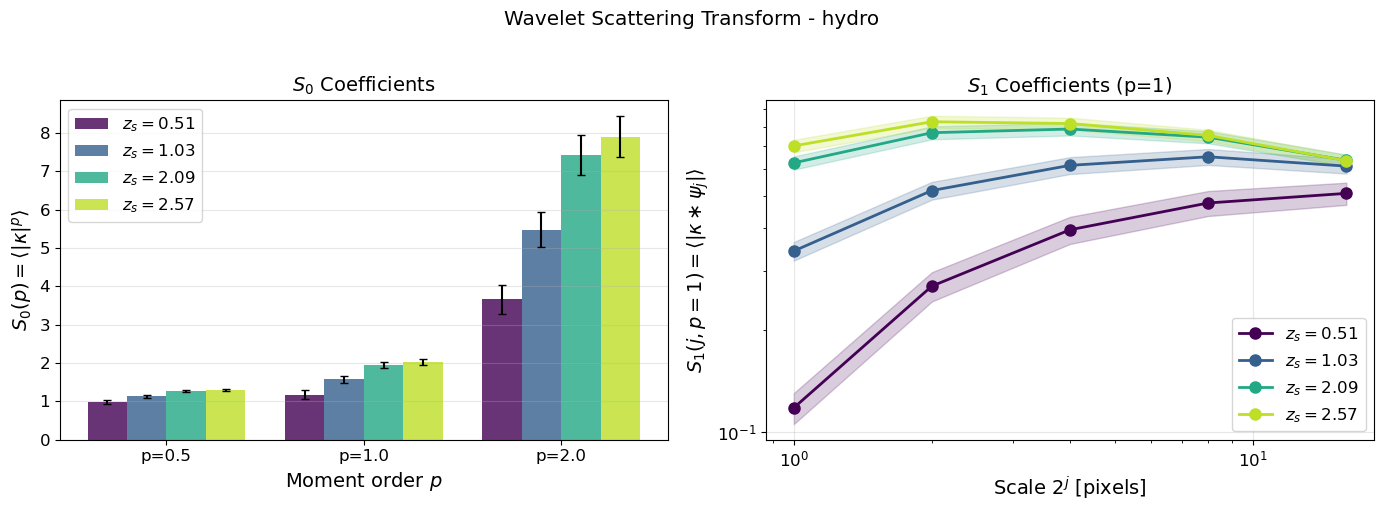

S0 shape: (2000, 4, 3), S1 shape: (2000, 4, 5, 3)
Scales: [ 1.  2.  4.  8. 16.], Moments: [0.5 1.  2. ]


In [9]:
# Plot Wavelet Scattering Transform
if all(k in data for k in ['S0', 'S1', 'wst_scales', 'wst_moments']):
    S0 = data['S0']  # Shape: (N_real, N_z, N_moments)
    S1 = data['S1']  # Shape: (N_real, N_z, N_scales, N_moments)
    scales = data['wst_scales']
    moments = data['wst_moments']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    moment_labels = [f'p={p}' for p in moments]
    
    # S0 plot (bar chart)
    ax = axes[0]
    x = np.arange(len(moments))
    width = 0.2
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        S0_mean = np.nanmean(S0[:, z_idx, :], axis=0)
        S0_std = np.nanstd(S0[:, z_idx, :], axis=0)
        ax.bar(x + z_idx * width, S0_mean, width, color=color, label=f'$z_s = {z:.2f}$',
               yerr=S0_std, capsize=3, alpha=0.8)
    
    ax.set_xlabel('Moment order $p$')
    ax.set_ylabel(r'$S_0(p) = \langle |\kappa|^p \rangle$')
    ax.set_title(r'$S_0$ Coefficients')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(moment_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # S1 plot (vs scale, for p=1)
    ax = axes[1]
    p_idx = 1  # p=1.0
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        S1_mean = np.nanmean(S1[:, z_idx, :, p_idx], axis=0)
        S1_std = np.nanstd(S1[:, z_idx, :, p_idx], axis=0)
        ax.loglog(scales, S1_mean, 'o-', color=color, lw=2, ms=8, label=f'$z_s = {z:.2f}$')
        ax.fill_between(scales, S1_mean - S1_std, S1_mean + S1_std, color=color, alpha=0.2)
    
    ax.set_xlabel('Scale $2^j$ [pixels]')
    ax.set_ylabel(r'$S_1(j, p=1) = \langle |\kappa \ast \psi_j| \rangle$')
    ax.set_title(r'$S_1$ Coefficients (p=1)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'Wavelet Scattering Transform - {MODEL}', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"S0 shape: {S0.shape}, S1 shape: {S1.shape}")
    print(f"Scales: {scales}, Moments: {moments}")
else:
    print("WST data not available")

---
## 8. Bispectrum

The bispectrum measures three-point correlations in Fourier space, quantifying non-Gaussianity:

$$B(\ell_1, \ell_2, \ell_3) = \langle \tilde{\kappa}(\boldsymbol{\ell}_1) \tilde{\kappa}(\boldsymbol{\ell}_2) \tilde{\kappa}(\boldsymbol{\ell}_3) \rangle$$

with $\boldsymbol{\ell}_1 + \boldsymbol{\ell}_2 + \boldsymbol{\ell}_3 = 0$ (triangle closure). We compute four configurations:

| Configuration | Triangle Shape | Estimator |
|--------------|----------------|-----------|
| **Equilateral** | $\ell_1 \approx \ell_2 \approx \ell_3$ | $\langle \kappa(\ell)^3 \rangle$ |
| **Squeezed** | $\ell_1 \ll \ell_2 \approx \ell_3$ | $\langle \kappa_\text{low} \cdot |\kappa(\ell)|^2 \rangle$ |
| **Folded** | $\ell_1 \approx 2\ell_2 \approx 2\ell_3$ | $\langle \kappa(\ell) \cdot \kappa(\ell/2)^2 \rangle$ |
| **Isosceles** | $\ell_1 = \ell_2 \neq \ell_3$ | $\langle |\kappa(\ell)|^2 \cdot \kappa(\ell') \rangle$ |

Different configurations are sensitive to different physical processes and halo masses.

/tmp/ipykernel_620222/62524414.py:25: RuntimeWarning: Mean of empty slice
  bispec_mean = np.nanmean(bispec[:, z_idx, :], axis=0)
/mnt/home/mlee1/venvs/hydro_replace/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


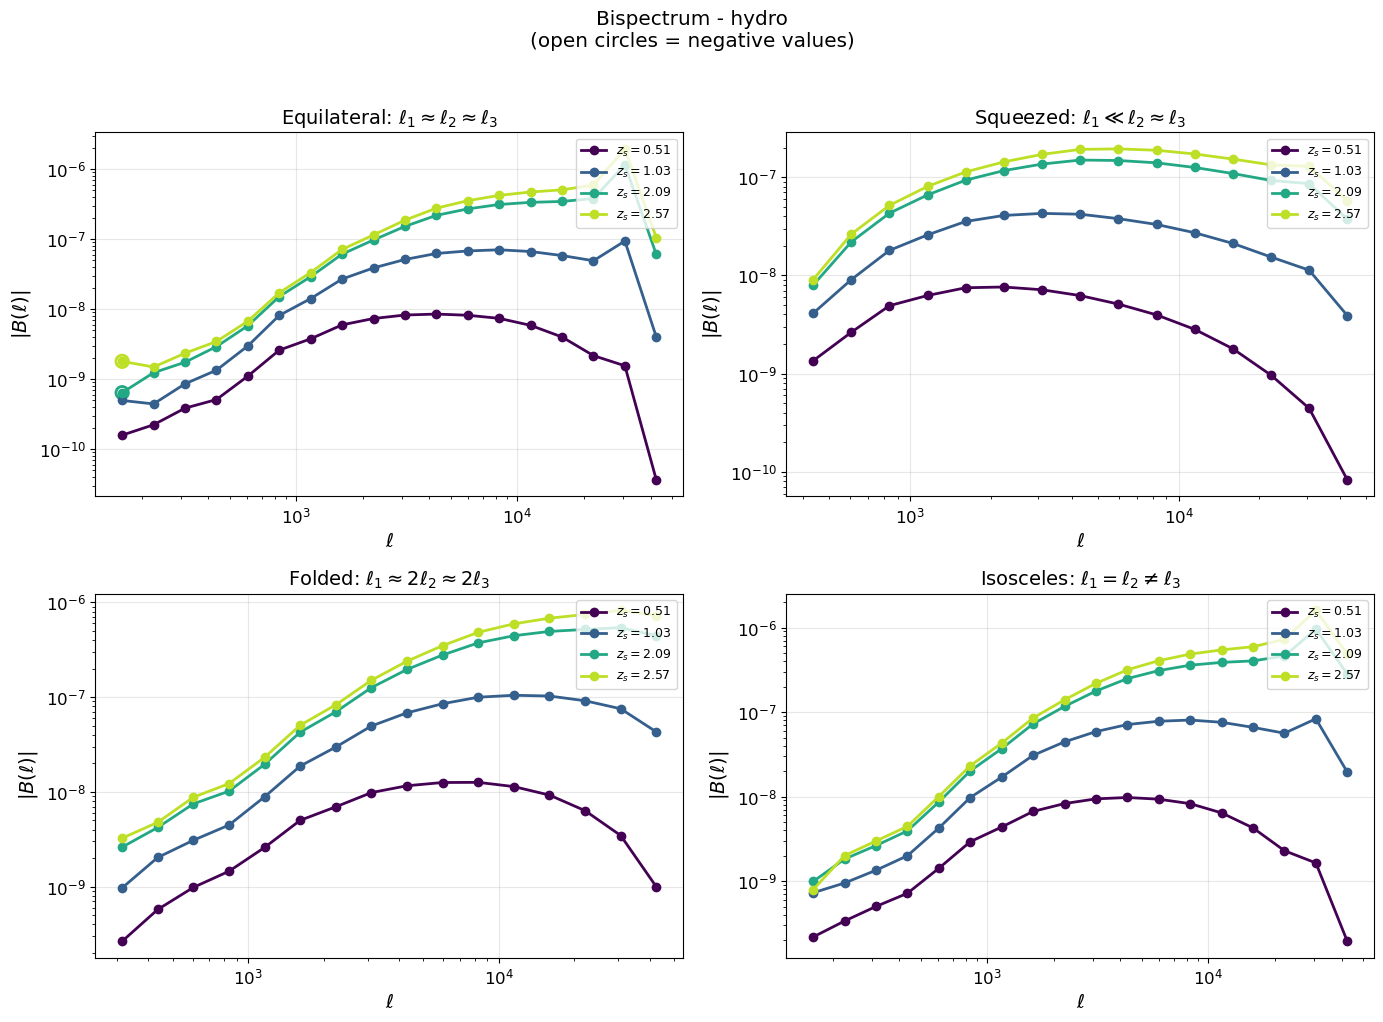

Bispectrum ell bins: 19
Bispectrum shape: (2000, 4, 19) (N_real, N_z, N_ell)


In [10]:
# Plot Bispectrum
bispec_keys = ['bispec_equilateral', 'bispec_squeezed', 'bispec_folded', 'bispec_isosceles']
if 'bispec_ell' in data and any(k in data for k in bispec_keys):
    ell_bispec = data['bispec_ell']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    configs = ['equilateral', 'squeezed', 'folded', 'isosceles']
    config_titles = [
        r'Equilateral: $\ell_1 \approx \ell_2 \approx \ell_3$',
        r'Squeezed: $\ell_1 \ll \ell_2 \approx \ell_3$',
        r'Folded: $\ell_1 \approx 2\ell_2 \approx 2\ell_3$',
        r'Isosceles: $\ell_1 = \ell_2 \neq \ell_3$'
    ]
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for ax, config, title in zip(axes, configs, config_titles):
        key = f'bispec_{config}'
        if key in data:
            bispec = data[key]  # Shape: (N_real, N_z, N_ell)
            
            for z_idx, (z, color) in enumerate(zip(source_z, colors)):
                bispec_mean = np.nanmean(bispec[:, z_idx, :], axis=0)
                bispec_std = np.nanstd(bispec[:, z_idx, :], axis=0)
                
                # Handle negative values with abs and sign
                sign = np.sign(bispec_mean)
                abs_bispec = np.abs(bispec_mean)
                
                ax.loglog(ell_bispec, abs_bispec, 'o-', color=color, lw=2, ms=6, 
                         label=f'$z_s = {z:.2f}$')
                
                # Mark negative values with open circles
                neg_mask = sign < 0
                if np.any(neg_mask):
                    ax.scatter(ell_bispec[neg_mask], abs_bispec[neg_mask], 
                              facecolors='none', edgecolors=color, s=80, linewidths=2)
            
            ax.set_xlabel(r'$\ell$')
            ax.set_ylabel(r'$|B(\ell)|$')
            ax.set_title(title)
            ax.legend(loc='upper right', fontsize=9)
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', 
                   transform=ax.transAxes)
            ax.set_title(title)
    
    fig.suptitle(f'Bispectrum - {MODEL}\n(open circles = negative values)', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"Bispectrum ell bins: {len(ell_bispec)}")
    if bispec_keys[0] in data:
        print(f"Bispectrum shape: {data[bispec_keys[0]].shape} (N_real, N_z, N_ell)")
else:
    print("Bispectrum data not available")

---
## Summary Statistics Table

Quick overview of all statistics computed:

In [11]:
# Summary table
print(f"Statistics Summary for: {MODEL}")
print("=" * 70)
print(f"{'Statistic':<25} {'Shape':<30} {'Description'}")
print("-" * 70)

stat_info = [
    ('Pk', 'Power spectrum P(k)'),
    ('k_bins', 'Wavenumber bins'),
    ('Cl', 'Angular power spectrum C_ℓ'),
    ('ell_bins', 'Multipole bins'),
    ('peaks', 'Peak counts'),
    ('minima', 'Minima counts'),
    ('pdf', 'Pixel PDF'),
    ('sn_bin_edges', 'S/N bin edges'),
    ('V0', 'Minkowski V0 (area)'),
    ('V1', 'Minkowski V1 (perimeter)'),
    ('V2', 'Minkowski V2 (Euler)'),
    ('mf_thresholds', 'MF threshold values'),
    ('S0', 'WST zeroth order'),
    ('S1', 'WST first order'),
    ('wst_scales', 'WST scale factors'),
    ('wst_moments', 'WST moment orders'),
    ('bispec_ell', 'Bispectrum ℓ bins'),
    ('bispec_equilateral', 'Bispectrum (equilateral)'),
    ('bispec_squeezed', 'Bispectrum (squeezed)'),
    ('bispec_folded', 'Bispectrum (folded)'),
    ('bispec_isosceles', 'Bispectrum (isosceles)'),
]

for key, desc in stat_info:
    if key in data:
        shape_str = str(data[key].shape)
        print(f"{key:<25} {shape_str:<30} {desc}")
    else:
        print(f"{key:<25} {'N/A':<30} {desc}")

print("-" * 70)
print(f"\nTotal realizations: {attrs.get('N_LP', 'N/A')} LPs × {attrs.get('N_RUNS', 'N/A')} runs")
print(f"Source redshifts: {list(source_z)}")

Statistics Summary for: hydro
Statistic                 Shape                          Description
----------------------------------------------------------------------
Pk                        (20, 40, 2896)                 Power spectrum P(k)
k_bins                    (2896,)                        Wavenumber bins
Cl                        (2000, 4, 724)                 Angular power spectrum C_ℓ
ell_bins                  (724,)                         Multipole bins
peaks                     (2000, 4, 50)                  Peak counts
minima                    (2000, 4, 50)                  Minima counts
pdf                       (2000, 4, 50)                  Pixel PDF
sn_bin_edges              (51,)                          S/N bin edges
V0                        (2000, 4, 51)                  Minkowski V0 (area)
V1                        (2000, 4, 51)                  Minkowski V1 (perimeter)
V2                        (2000, 4, 51)                  Minkowski V2 (Euler)
mf_thresh

---
# Hydro vs DMO Comparison

This section compares the hydrodynamical simulation (with full baryonic physics) to the dark matter only (DMO) simulation. The ratio $S_\text{Hydro}/S_\text{DMO}$ quantifies the **baryonic suppression/enhancement** for each statistic.

Key baryonic effects:
- **AGN feedback**: Expels gas from halos, reducing small-scale power
- **Cooling & star formation**: Concentrates baryons, can enhance central densities
- **Net effect**: Typically suppression at $k \gtrsim 1 \, h/\text{Mpc}$ or $\ell \gtrsim 1000$

In [12]:
# Load both DMO and Hydro statistics
def load_model_stats(model_name):
    """Load all statistics for a model."""
    stats_path = STATS_BASE / model_name / 'stats.h5'
    if not stats_path.exists():
        print(f"WARNING: {stats_path} not found")
        return None, None
    
    with h5py.File(stats_path, 'r') as f:
        data = {}
        for key in f.keys():
            if isinstance(f[key], h5py.Dataset):
                data[key] = f[key][:]
        attrs = dict(f.attrs)
    return data, attrs

# Load both models
print("Loading DMO and Hydro statistics...")
data_dmo, attrs_dmo = load_model_stats('dmo')
data_hydro, attrs_hydro = load_model_stats('hydro')

if data_dmo is not None:
    print(f"DMO: {len(data_dmo)} datasets loaded")
if data_hydro is not None:
    print(f"Hydro: {len(data_hydro)} datasets loaded")

# Use DMO source redshifts
source_z = attrs_dmo.get('source_redshifts', [0.5, 1.0, 2.0, 2.5]) if attrs_dmo else [0.5, 1.0, 2.0, 2.5]

Loading DMO and Hydro statistics...


DMO: 22 datasets loaded
Hydro: 22 datasets loaded


## Power Spectrum Ratio $P_\text{Hydro}(k) / P_\text{DMO}(k)$

The matter power spectrum suppression due to baryons is the classic test of baryonic effects. We expect:
- Unity at large scales ($k \lesssim 0.1 \, h/\text{Mpc}$)
- Suppression of 10-30% at $k \sim 1-10 \, h/\text{Mpc}$ (AGN feedback)
- Possible enhancement at very small scales (star formation)

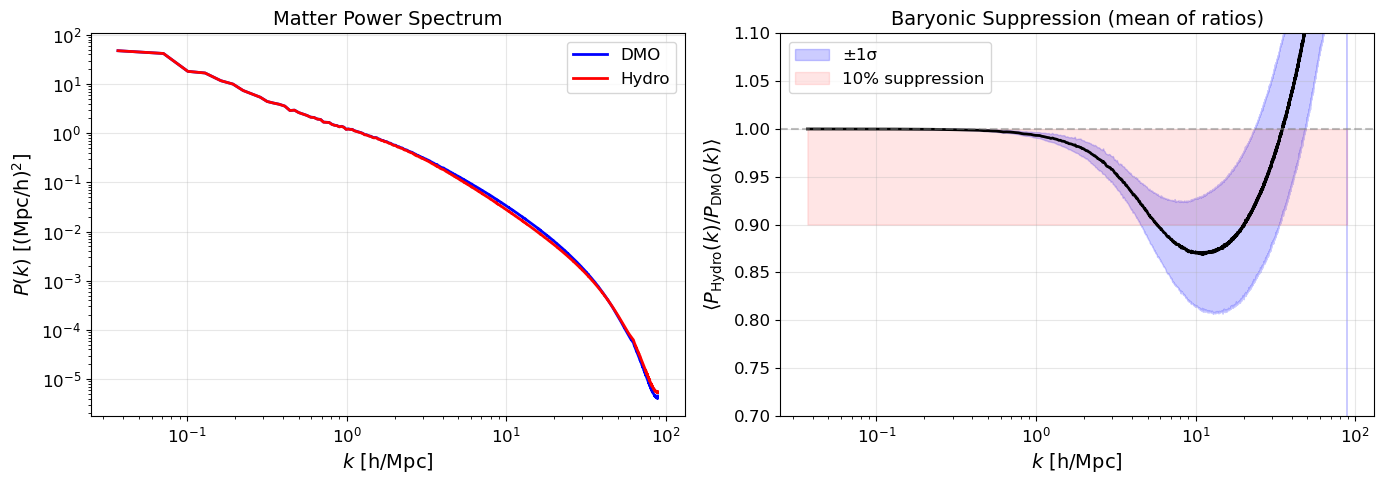

P(k) data not available for both models


In [13]:
# P(k) ratio: Hydro / DMO
if data_dmo is not None and data_hydro is not None and 'Pk' in data_dmo and 'Pk' in data_hydro:
    Pk_dmo = data_dmo['Pk']
    Pk_hydro = data_hydro['Pk']
    k = data_dmo['k_bins']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Absolute P(k)
    ax = axes[0]
    Pk_dmo_mean = np.nanmean(Pk_dmo, axis=(0, 1))
    Pk_hydro_mean = np.nanmean(Pk_hydro, axis=(0, 1))
    
    ax.loglog(k, Pk_dmo_mean, 'b-', lw=2, label='DMO')
    ax.loglog(k, Pk_hydro_mean, 'r-', lw=2, label='Hydro')
    ax.set_xlabel(r'$k$ [h/Mpc]')
    ax.set_ylabel(r'$P(k)$ [(Mpc/h)$^2$]')
    ax.set_title('Matter Power Spectrum')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right: Ratio - compute per-realization ratio then average
    ax = axes[1]
    # Compute ratio per LP/plane, then average (cancels cosmic variance)
    ratio_per_real = Pk_hydro / Pk_dmo  # Shape: (N_LP, N_planes, N_k)
    ratio_mean = np.nanmean(ratio_per_real, axis=(0, 1))
    ratio_std = np.nanstd(ratio_per_real, axis=(0, 1))
    
    ax.semilogx(k, ratio_mean, 'k-', lw=2)
    ax.fill_between(k, ratio_mean - ratio_std, ratio_mean + ratio_std, alpha=0.2, color='blue', label='±1σ')
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.fill_between(k, 0.9, 1.0, alpha=0.1, color='red', label='10% suppression')
    ax.set_xlabel(r'$k$ [h/Mpc]')
    ax.set_ylabel(r'$\langle P_\text{Hydro}(k) / P_\text{DMO}(k) \rangle$')
    ax.set_title('Baryonic Suppression (mean of ratios)')
    ax.set_ylim(0.7, 1.1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print max suppression

    min_ratio = np.nanmin(ratio_mean)    
    print("P(k) data not available for both models")

    k_min = k[np.nanargmin(ratio_mean)]
else:
    print(f"Maximum suppression: {(1-min_ratio)*100:.1f}% at k = {k_min:.2f} h/Mpc")

## Angular Power Spectrum Ratio $C_\ell^\text{Hydro} / C_\ell^\text{DMO}$

The convergence power spectrum integrates the matter power spectrum along the line of sight. The baryonic suppression:
- Appears at $\ell \gtrsim 1000$ (corresponding to $k \gtrsim 1 \, h/\text{Mpc}$)
- Depends on source redshift due to different weight functions

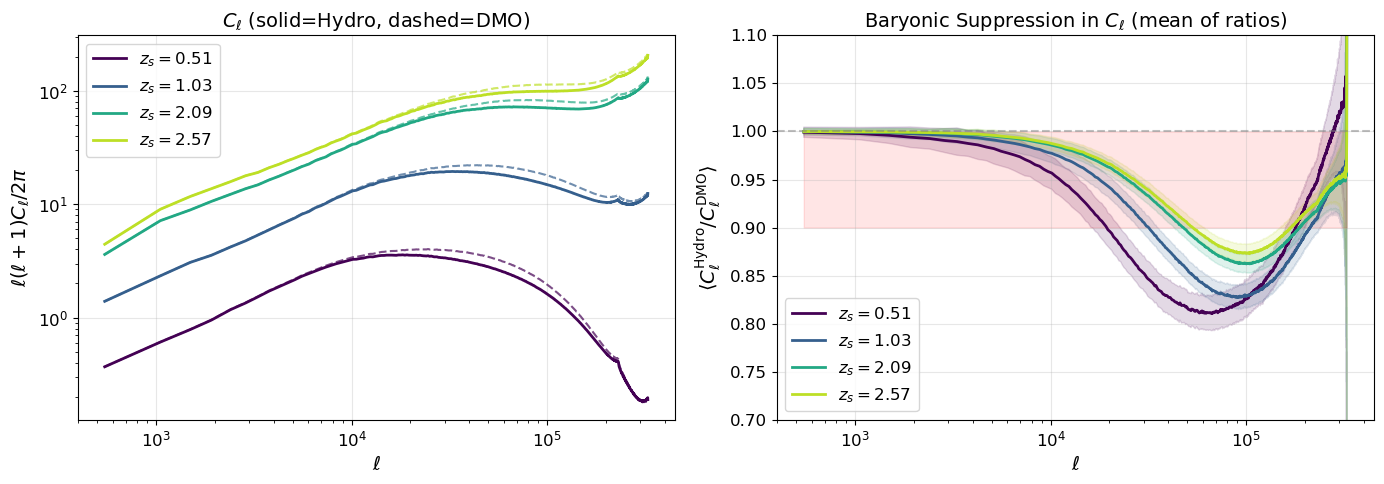

In [14]:
# C_ell ratio: Hydro / DMO
if data_dmo is not None and data_hydro is not None and 'Cl' in data_dmo and 'Cl' in data_hydro:
    Cl_dmo = data_dmo['Cl']
    Cl_hydro = data_hydro['Cl']
    ell = data_dmo['ell_bins']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute C_ell
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        Cl_dmo_mean = np.nanmean(Cl_dmo[:, z_idx, :], axis=0)
        Cl_hydro_mean = np.nanmean(Cl_hydro[:, z_idx, :], axis=0)
        
        ax.loglog(ell, ell * (ell + 1) * Cl_dmo_mean / (2 * np.pi), 
                  '--', color=color, lw=1.5, alpha=0.7)
        ax.loglog(ell, ell * (ell + 1) * Cl_hydro_mean / (2 * np.pi), 
                  '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\ell(\ell+1)C_\ell / 2\pi$')
    ax.set_title(r'$C_\ell$ (solid=Hydro, dashed=DMO)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right: Ratio - compute per-realization ratio then average
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Compute ratio per realization, then average (cancels cosmic variance)
        ratio_per_real = Cl_hydro[:, z_idx, :] / Cl_dmo[:, z_idx, :]  # Shape: (N_real, N_ell)
        ratio_mean = np.nanmean(ratio_per_real, axis=0)
        ratio_std = np.nanstd(ratio_per_real, axis=0)
        
        ax.semilogx(ell, ratio_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(ell, ratio_mean - ratio_std, ratio_mean + ratio_std, color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.fill_between(ell, 0.9, 1.0, alpha=0.1, color='red')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\langle C_\ell^\text{Hydro} / C_\ell^\text{DMO} \rangle$')
    ax.set_title('Baryonic Suppression in $C_\ell$ (mean of ratios)')
    ax.set_ylim(0.7, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

else:    print("C_ℓ data not available for both models")

## Peak Counts Ratio

Peak counts are sensitive to baryonic effects because:
- High-$\nu$ peaks trace massive halos where AGN feedback is strongest
- Baryons modify the halo mass-concentration relation
- The response is **ν-dependent**: different at low vs high S/N

/tmp/ipykernel_620222/3266292962.py:35: RuntimeWarning: invalid value encountered in divide
  ratio = N_H / N_D
/tmp/ipykernel_620222/3266292962.py:38: RuntimeWarning: divide by zero encountered in divide
  ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)
/tmp/ipykernel_620222/3266292962.py:38: RuntimeWarning: invalid value encountered in multiply
  ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)


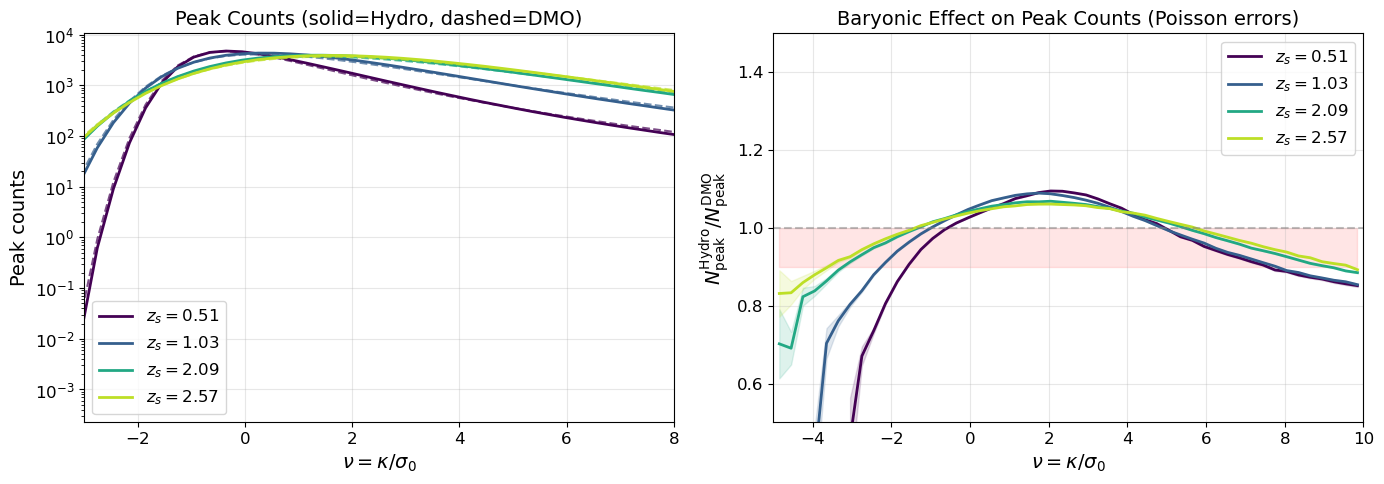

In [15]:
# Peak counts ratio: Hydro / DMO
if data_dmo is not None and data_hydro is not None and 'peaks' in data_dmo and 'peaks' in data_hydro:
    peaks_dmo = data_dmo['peaks']
    peaks_hydro = data_hydro['peaks']
    sn_edges = data_dmo['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute counts
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        peaks_dmo_mean = np.nanmean(peaks_dmo[:, z_idx, :], axis=0)
        peaks_hydro_mean = np.nanmean(peaks_hydro[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, peaks_dmo_mean, '--', color=color, lw=1.5, alpha=0.7)
        ax.semilogy(sn_centers, peaks_hydro_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Peak counts')
    ax.set_title('Peak Counts (solid=Hydro, dashed=DMO)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-3, 8)
    
    # Right: Ratio with Poisson errors from total counts
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Sum over all realizations for total counts
        N_H = np.nansum(peaks_hydro[:, z_idx, :], axis=0)  # Total Hydro counts per bin
        N_D = np.nansum(peaks_dmo[:, z_idx, :], axis=0)    # Total DMO counts per bin
        
        # Ratio of total counts
        ratio = N_H / N_D
        
        # Poisson error on ratio: σ_R/R = sqrt(1/N_H + 1/N_D)
        ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)
        
        # Mask where counts are too low
        mask = (N_D > 10) & (N_H > 10)
        
        ax.plot(sn_centers[mask], ratio[mask], color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers[mask], (ratio - ratio_err)[mask], (ratio + ratio_err)[mask], color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.fill_between(sn_centers, 0.9, 1.0, alpha=0.1, color='red')
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel(r'$N_\text{peak}^\text{Hydro} / N_\text{peak}^\text{DMO}$')
    ax.set_title('Baryonic Effect on Peak Counts (Poisson errors)')
    ax.set_xlim(-5, 10)
    ax.set_ylim(0.5, 1.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()


    plt.show()    

else:       print("Peak counts data not available for both models")

## Minima Counts Ratio

Minima (voids) are also affected by baryons:
- AGN feedback pushes gas into voids, potentially making them less underdense
- The effect is generally smaller than for peaks

/tmp/ipykernel_620222/761289103.py:35: RuntimeWarning: invalid value encountered in divide
  ratio = N_H / N_D
/tmp/ipykernel_620222/761289103.py:38: RuntimeWarning: divide by zero encountered in divide
  ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)


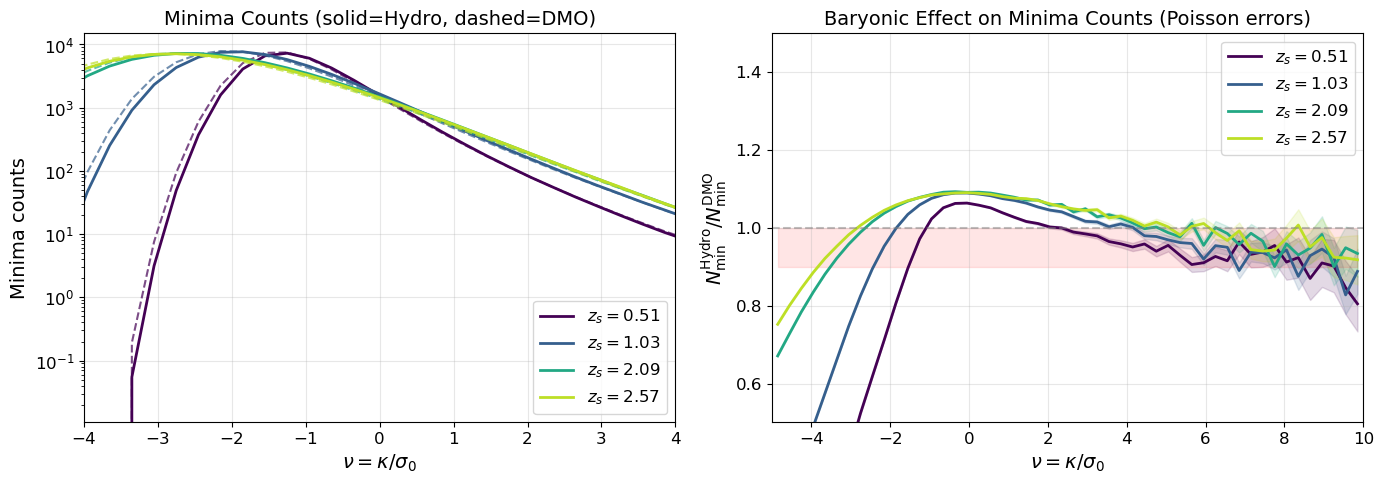

In [16]:
# Minima counts ratio: Hydro / DMO
if data_dmo is not None and data_hydro is not None and 'minima' in data_dmo and 'minima' in data_hydro:
    minima_dmo = data_dmo['minima']
    minima_hydro = data_hydro['minima']
    sn_edges = data_dmo['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute counts
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        minima_dmo_mean = np.nanmean(minima_dmo[:, z_idx, :], axis=0)
        minima_hydro_mean = np.nanmean(minima_hydro[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, minima_dmo_mean, '--', color=color, lw=1.5, alpha=0.7)
        ax.semilogy(sn_centers, minima_hydro_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Minima counts')
    ax.set_title('Minima Counts (solid=Hydro, dashed=DMO)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 4)
    
    # Right: Ratio with Poisson errors from total counts
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Sum over all realizations for total counts
        N_H = np.nansum(minima_hydro[:, z_idx, :], axis=0)  # Total Hydro counts per bin
        N_D = np.nansum(minima_dmo[:, z_idx, :], axis=0)    # Total DMO counts per bin
        
        # Ratio of total counts
        ratio = N_H / N_D
        
        # Poisson error on ratio: σ_R/R = sqrt(1/N_H + 1/N_D)
        ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)
        
        # Mask where counts are too low
        mask = (N_D > 10) & (N_H > 10)
        
        ax.plot(sn_centers[mask], ratio[mask], color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers[mask], (ratio - ratio_err)[mask], (ratio + ratio_err)[mask], color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.fill_between(sn_centers, 0.9, 1.0, alpha=0.1, color='red')
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel(r'$N_\text{min}^\text{Hydro} / N_\text{min}^\text{DMO}$')
    ax.set_title('Baryonic Effect on Minima Counts (Poisson errors)')
    ax.set_xlim(-5, 10)
    ax.set_ylim(0.5, 1.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    

    plt.tight_layout()    


    plt.show()
else:     print("Minima counts data not available for both models")


## PDF Ratio

The one-point PDF ratio shows how baryons modify the distribution of convergence values:
- Suppression at high $\nu$ (fewer high-density peaks)
- Possible enhancement near $\nu \sim 0$ (redistribution of matter)

/tmp/ipykernel_620222/2373452532.py:35: RuntimeWarning: invalid value encountered in divide
  ratio = N_H / N_D
/tmp/ipykernel_620222/2373452532.py:38: RuntimeWarning: divide by zero encountered in divide
  ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)


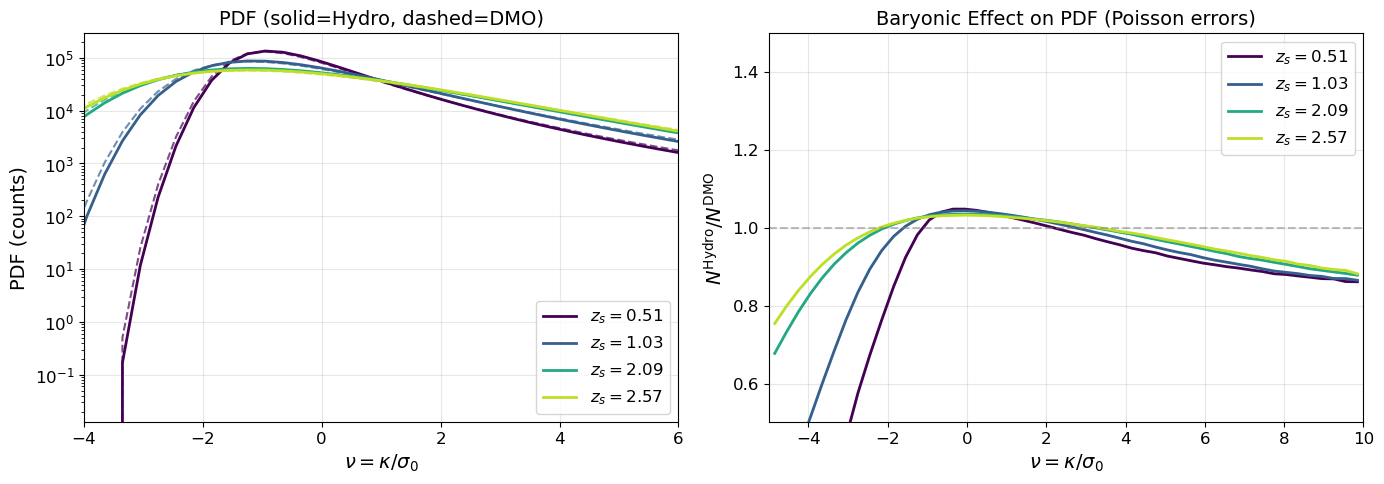

In [17]:
# PDF ratio: Hydro / DMO
if data_dmo is not None and data_hydro is not None and 'pdf' in data_dmo and 'pdf' in data_hydro:
    pdf_dmo = data_dmo['pdf']
    pdf_hydro = data_hydro['pdf']
    sn_edges = data_dmo['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute PDF
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        pdf_dmo_mean = np.nanmean(pdf_dmo[:, z_idx, :], axis=0)
        pdf_hydro_mean = np.nanmean(pdf_hydro[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, pdf_dmo_mean, '--', color=color, lw=1.5, alpha=0.7)
        ax.semilogy(sn_centers, pdf_hydro_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('PDF (counts)')
    ax.set_title('PDF (solid=Hydro, dashed=DMO)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 6)
    
    # Right: Ratio with Poisson errors from total counts
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Sum over all realizations for total counts
        N_H = np.nansum(pdf_hydro[:, z_idx, :], axis=0)  # Total Hydro counts per bin
        N_D = np.nansum(pdf_dmo[:, z_idx, :], axis=0)    # Total DMO counts per bin
        
        # Ratio of total counts
        ratio = N_H / N_D
        
        # Poisson error on ratio: σ_R/R = sqrt(1/N_H + 1/N_D)
        ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)
        
        # Mask where counts are too low
        mask = (N_D > 100) & (N_H > 100)
        
        ax.plot(sn_centers[mask], ratio[mask], color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers[mask], (ratio - ratio_err)[mask], (ratio + ratio_err)[mask], color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel(r'$N^\text{Hydro} / N^\text{DMO}$')
    ax.set_title('Baryonic Effect on PDF (Poisson errors)')
    ax.set_xlim(-5, 10)
    ax.set_ylim(0.5, 1.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("PDF data not available for both models")

## Minkowski Functionals Ratio

The three Minkowski functionals capture different morphological aspects:
- **$V_0$ (Area)**: Fraction of field above threshold
- **$V_1$ (Perimeter)**: Boundary complexity
- **$V_2$ (Euler)**: Topology (connected regions - holes)

/tmp/ipykernel_620222/1811845748.py:46: RuntimeWarning: Mean of empty slice
  ratio_mean = np.nanmean(ratio_per_real, axis=0)


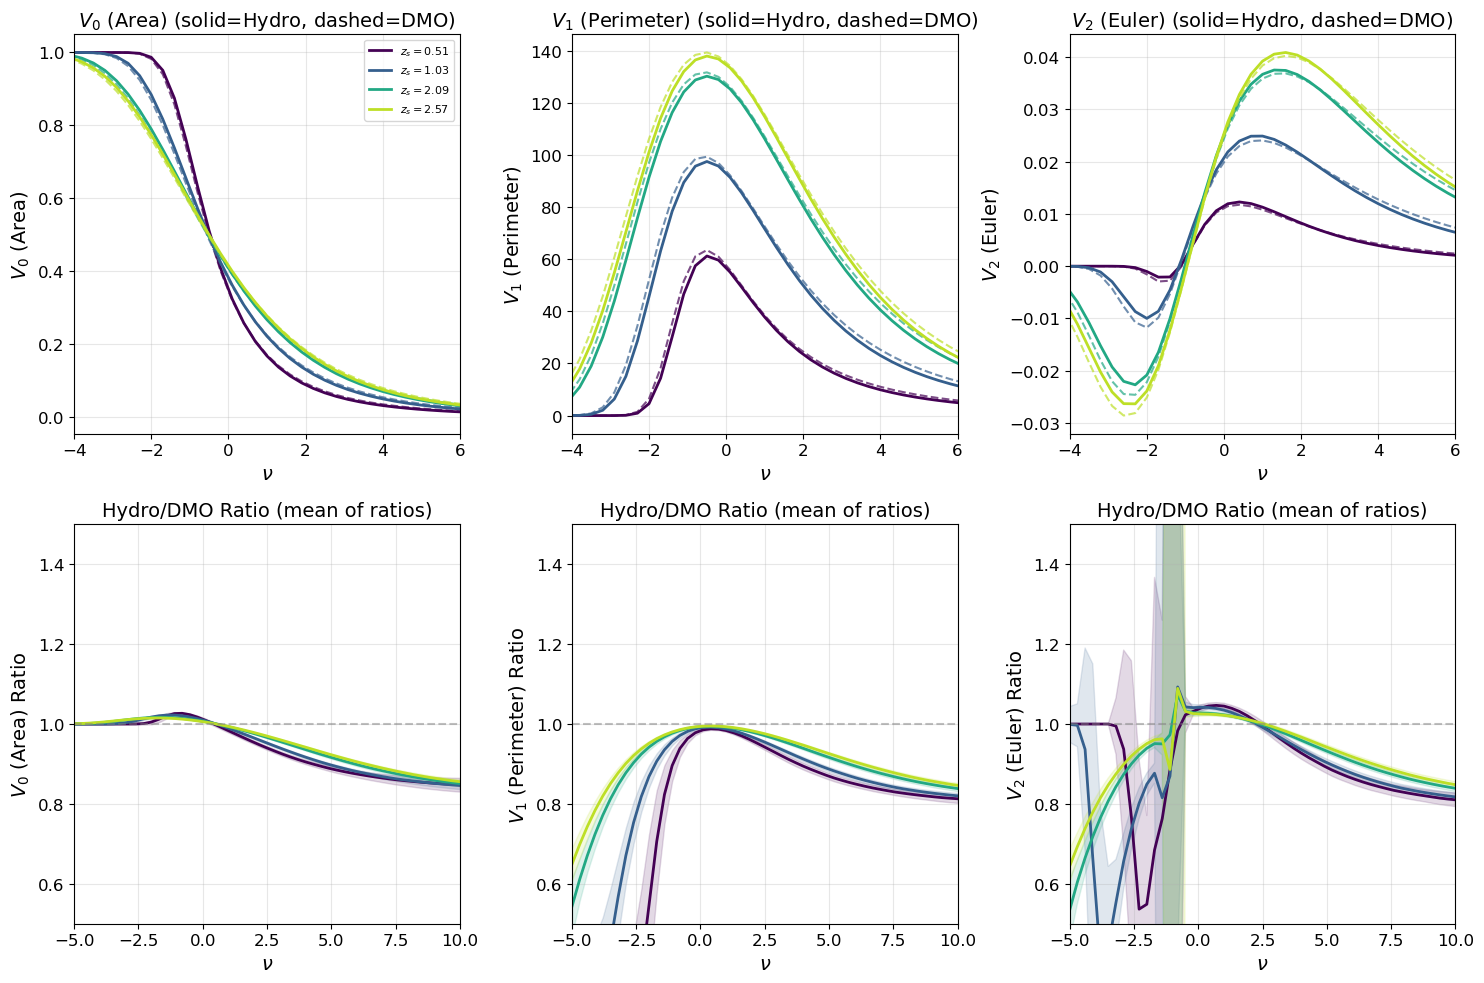

In [18]:
# Minkowski Functionals ratio: Hydro / DMO
mf_keys = ['V0', 'V1', 'V2']
if (data_dmo is not None and data_hydro is not None and 
    all(k in data_dmo for k in mf_keys) and all(k in data_hydro for k in mf_keys)):
    
    nu = data_dmo['mf_thresholds']
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    mf_titles = [r'$V_0$ (Area)', r'$V_1$ (Perimeter)', r'$V_2$ (Euler)']
    
    # Top row: Absolute values
    for col, (key, title) in enumerate(zip(mf_keys, mf_titles)):
        ax = axes[0, col]
        MF_dmo = data_dmo[key]
        MF_hydro = data_hydro[key]
        
        for z_idx, (z, color) in enumerate(zip(source_z, colors)):
            MF_dmo_mean = np.nanmean(MF_dmo[:, z_idx, :], axis=0)
            MF_hydro_mean = np.nanmean(MF_hydro[:, z_idx, :], axis=0)
            
            ax.plot(nu, MF_dmo_mean, '--', color=color, lw=1.5, alpha=0.7)
            ax.plot(nu, MF_hydro_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
        
        ax.set_xlabel(r'$\nu$')
        ax.set_ylabel(title)
        ax.set_title(f'{title} (solid=Hydro, dashed=DMO)')
        if col == 0:
            ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-4, 6)
    
    # Bottom row: Ratios - compute per-realization ratio then average
    for col, (key, title) in enumerate(zip(mf_keys, mf_titles)):
        ax = axes[1, col]
        MF_dmo = data_dmo[key]
        MF_hydro = data_hydro[key]
        
        for z_idx, (z, color) in enumerate(zip(source_z, colors)):
            # Compute ratio per realization (cancels cosmic variance)
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio_per_real = MF_hydro[:, z_idx, :] / MF_dmo[:, z_idx, :]
                # Mask where DMO is too small (per realization)
                ratio_per_real = np.where(np.abs(MF_dmo[:, z_idx, :]) > 1e-6, ratio_per_real, np.nan)
            
            ratio_mean = np.nanmean(ratio_per_real, axis=0)
            ratio_std = np.nanstd(ratio_per_real, axis=0)
            
            ax.plot(nu, ratio_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
            ax.fill_between(nu, ratio_mean - ratio_std, ratio_mean + ratio_std, color=color, alpha=0.15)
        
        ax.axhline(1, color='gray', ls='--', alpha=0.5)
        ax.set_xlabel(r'$\nu$')
        ax.set_ylabel(f'{title} Ratio')
        ax.set_title(f'Hydro/DMO Ratio (mean of ratios)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-5, 10)
        ax.set_ylim(0.5, 1.5)
    
    plt.tight_layout()
    plt.show()
else:
    print("Minkowski functionals data not available for both models")

## Wavelet Scattering Transform Ratio

The WST captures non-Gaussian information at multiple scales. The ratio shows:
- How baryons affect the field amplitude ($S_0$)
- Scale-dependent modifications ($S_1$)

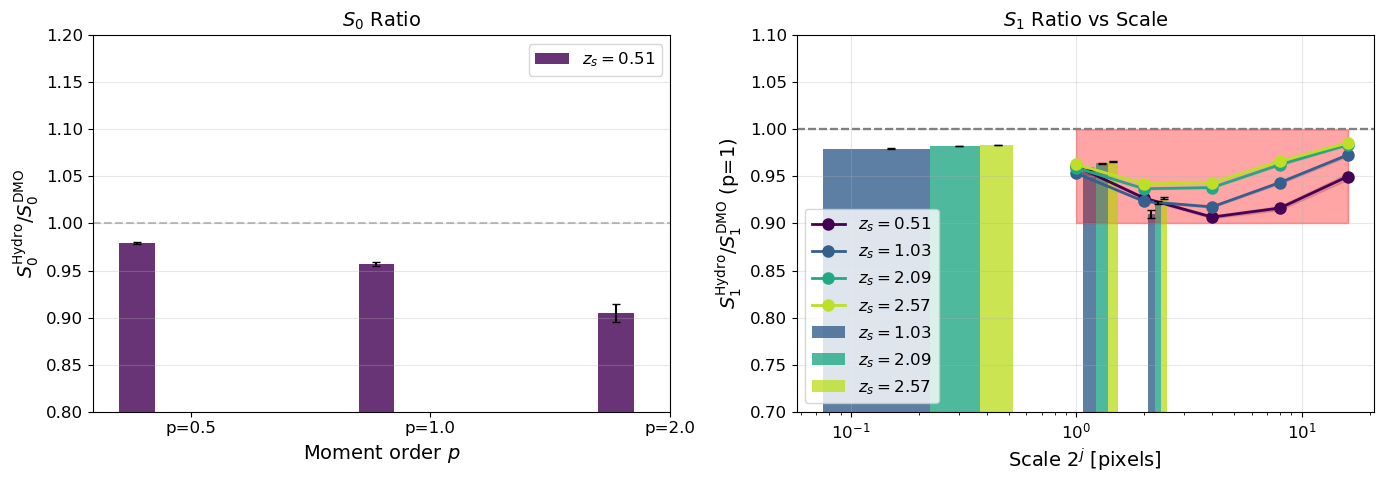

In [19]:
# WST ratio: Hydro / DMO
if (data_dmo is not None and data_hydro is not None and 
    'S0' in data_dmo and 'S1' in data_dmo and 'S0' in data_hydro and 'S1' in data_hydro):
    
    S0_dmo = data_dmo['S0']
    S0_hydro = data_hydro['S0']
    S1_dmo = data_dmo['S1']
    S1_hydro = data_hydro['S1']
    scales = data_dmo['wst_scales']
    moments = data_dmo['wst_moments']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: S0 ratio (bar chart)
    ax = axes[0]
    moment_labels = [f'p={p}' for p in moments]
    x = np.arange(len(moments))
    width = 0.15
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Per-realization ratio to cancel cosmic variance
        S0_ratio = S0_hydro[:, z_idx, :] / S0_dmo[:, z_idx, :]
        ratio_mean = np.nanmean(S0_ratio, axis=0)
        ratio_std = np.nanstd(S0_ratio, axis=0)
        
        ax.bar(x + z_idx * width, ratio_mean, width, color=color, label=f'$z_s = {z:.2f}$', alpha=0.8,
               yerr=ratio_std, capsize=3)
    
        ax.axhline(1, color='gray', ls='--', alpha=0.5)
        ax.set_xlabel('Moment order $p$')
        ax.set_ylabel(r'$S_0^\text{Hydro} / S_0^\text{DMO}$')
        ax.set_title(r'$S_0$ Ratio')
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(moment_labels)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0.8, 1.2)
        
        # Right: S1 ratio vs scale (for p=1)
        ax = axes[1]
        p_idx = 1  # p=1.0
        # Per-realization ratio to cancel cosmic variance
        S1_ratio = S1_hydro[:, z_idx, :, p_idx] / S1_dmo[:, z_idx, :, p_idx]
        ratio_mean = np.nanmean(S1_ratio, axis=0)
        ratio_std = np.nanstd(S1_ratio, axis=0)
        
        ax.semilogx(scales, ratio_mean, 'o-', color=color, lw=2, ms=8, label=f'$z_s = {z:.2f}$')
        ax.fill_between(scales, ratio_mean - ratio_std, ratio_mean + ratio_std, color=color, alpha=0.15)
        
        ax.axhline(1, color='gray', ls='--', alpha=0.5)
        ax.fill_between([scales.min(), scales.max()], 0.9, 1.0, alpha=0.1, color='red')
        ax.set_xlabel('Scale $2^j$ [pixels]')
        ax.set_ylabel(r'$S_1^\text{Hydro} / S_1^\text{DMO}$ (p=1)')
        ax.set_title(r'$S_1$ Ratio vs Scale')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.7, 1.1)
        
    plt.tight_layout()
    plt.show()

else:    print("WST data not available for both models")


## Bispectrum Ratio

The bispectrum measures three-point correlations. Different triangle configurations probe different physical scales and processes:
- **Equilateral**: Equal-sided triangles, sensitive to non-linear growth
- **Squeezed**: Long + short wavelengths, sensitive to halo bias
- **Folded**: Collinear configurations
- **Isosceles**: Two equal sides

/tmp/ipykernel_620222/2421785136.py:29: RuntimeWarning: Mean of empty slice
  ratio_mean = np.nanmean(B_ratio, axis=0)
/mnt/home/mlee1/venvs/hydro_replace/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


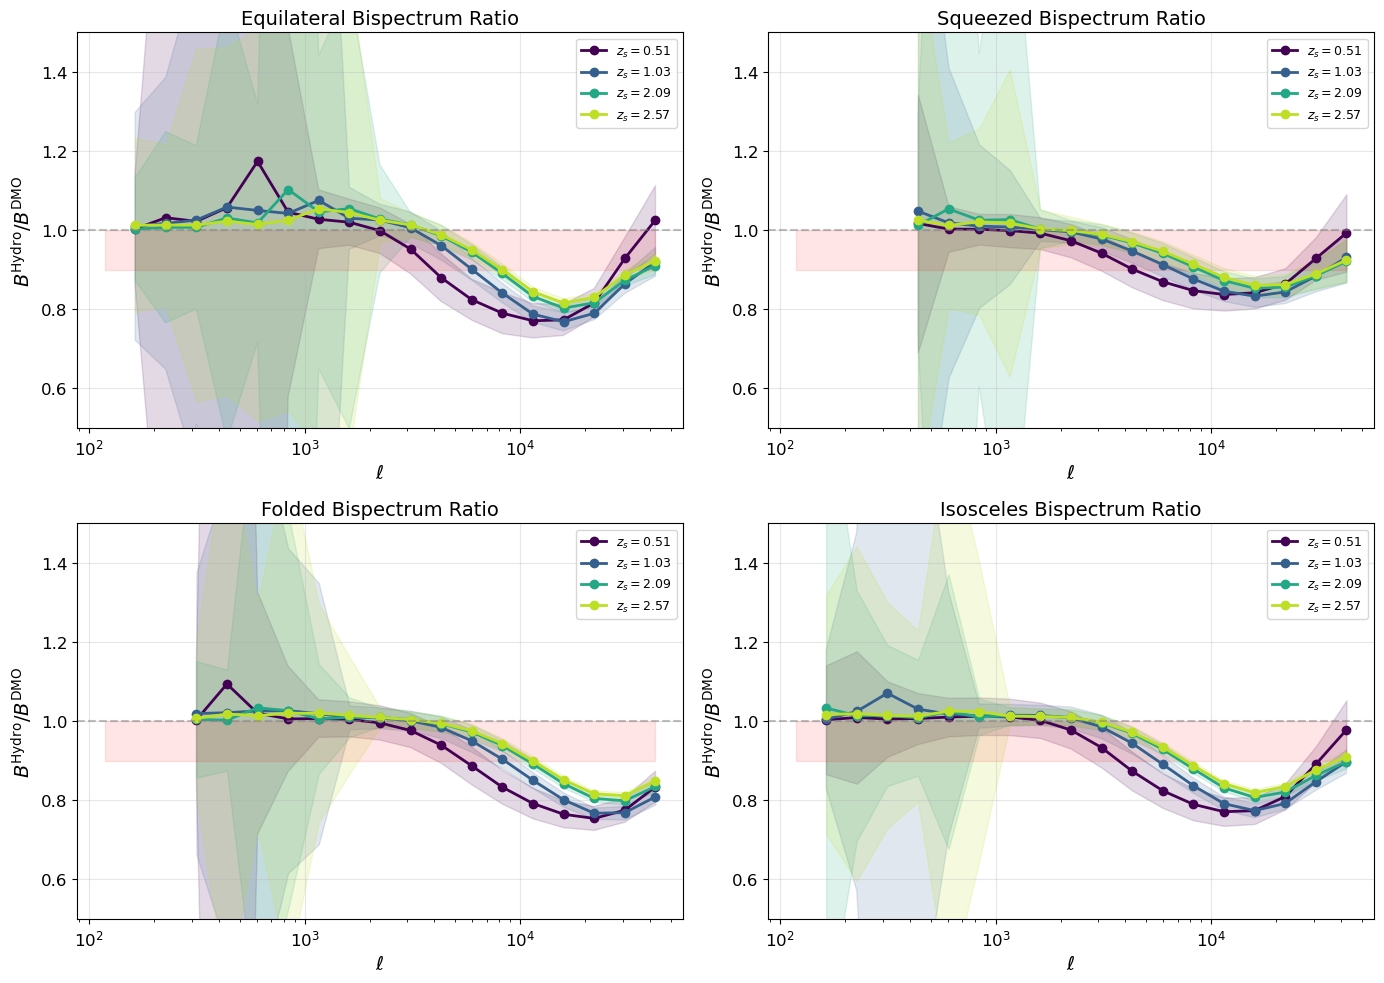

In [20]:
# Bispectrum ratio: Hydro / DMO
bispec_keys = ['bispec_equilateral', 'bispec_squeezed', 'bispec_folded', 'bispec_isosceles']
if (data_dmo is not None and data_hydro is not None and 'bispec_ell' in data_dmo and
    any(k in data_dmo for k in bispec_keys) and any(k in data_hydro for k in bispec_keys)):
    
    ell_bispec = data_dmo['bispec_ell']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    configs = ['equilateral', 'squeezed', 'folded', 'isosceles']
    config_titles = ['Equilateral', 'Squeezed', 'Folded', 'Isosceles']
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for ax, config, title in zip(axes, configs, config_titles):
        key = f'bispec_{config}'
        if key in data_dmo and key in data_hydro:
            bispec_dmo = data_dmo[key]
            bispec_hydro = data_hydro[key]
            
            for z_idx, (z, color) in enumerate(zip(source_z, colors)):
                # Per-realization ratio to cancel cosmic variance
                with np.errstate(divide='ignore', invalid='ignore'):
                    B_ratio = bispec_hydro[:, z_idx, :] / bispec_dmo[:, z_idx, :]
                    # Mask where values are too small or have opposite signs
                    bad = (np.abs(bispec_dmo[:, z_idx, :]) < 1e-12) | (np.sign(bispec_dmo[:, z_idx, :]) != np.sign(bispec_hydro[:, z_idx, :]))
                    B_ratio[bad] = np.nan
                
                ratio_mean = np.nanmean(B_ratio, axis=0)
                ratio_std = np.nanstd(B_ratio, axis=0)
                
                mask = ~np.isnan(ratio_mean)
                if np.any(mask):
                    ax.semilogx(ell_bispec[mask], ratio_mean[mask], 'o-', color=color, 
                               lw=2, ms=6, label=f'$z_s = {z:.2f}$')
                    ax.fill_between(ell_bispec[mask], (ratio_mean - ratio_std)[mask], 
                                   (ratio_mean + ratio_std)[mask], color=color, alpha=0.15)
            
            ax.axhline(1, color='gray', ls='--', alpha=0.5)
            ax.fill_between([ell_bispec.min(), ell_bispec.max()], 0.9, 1.0, alpha=0.1, color='red')
            ax.set_xlabel(r'$\ell$')
            ax.set_ylabel(r'$B^\text{Hydro}/B^\text{DMO}$')
            ax.set_title(f'{title} Bispectrum Ratio')
            ax.legend(loc='upper right', fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0.5, 1.5)
        else:
            ax.text(0.5, 0.5, f'{title} data not available', ha='center', va='center', 
                   transform=ax.transAxes)
            ax.set_title(f'{title} Bispectrum Ratio')
    
    plt.tight_layout()
    plt.show()

else:    print("Bispectrum data not available for both models")

## Summary: Baryonic Effects Across Statistics

The comparison above shows that baryonic physics affects weak lensing statistics in complex, **statistic-dependent** ways:

| Statistic | Typical Effect | Scale/Threshold Dependence |
|-----------|---------------|---------------------------|
| $P(k)$ | 10-30% suppression | Strongest at $k \sim 1-10$ h/Mpc |
| $C_\ell$ | 5-15% suppression | Strongest at $\ell \gtrsim 1000$ |
| Peak counts | Suppression at high $\nu$ | $\nu$-dependent |
| Minima | Smaller effect | Mainly at negative $\nu$ |
| PDF | Modified tails | Both high and low $\nu$ |
| Minkowski | Morphology changes | Threshold-dependent |
| WST | Scale-dependent | Smaller scales more affected |
| Bispectrum | Non-Gaussian effects | Configuration-dependent |

This motivates the **baryonic response formalism**: understanding which halos and radii contribute to these effects allows us to model and correct for baryonic physics in cosmological analyses.

In [ ]:
---
# Replace Model vs Hydro Comparison

This section compares a **Replace model** (DMO halos selectively replaced with Hydro counterparts) to the full **Hydro simulation**. If the Replace model captures the baryonic effect well, the ratio should be close to **1.0**.

The Replace model uses:
- **Mass threshold**: $M > M_\text{min}$ (halos above this mass are replaced)
- **Radius factor**: $\alpha$ (replacement extends to $\alpha \times R_{200}$)

If $S_\text{Replace} / S_\text{Hydro} \approx 1$, the Replace model fully captures the baryonic effect for statistic $S$.

In [31]:
# Load a Replace model to compare with Hydro
# Choose one of the cumulative models (M > 10^12, α = 5.0 should capture ~99% of baryonic effect)

REPLACE_MODEL = 'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0'

print(f"Loading Replace model: {REPLACE_MODEL}")
data_replace, attrs_replace = load_model_stats(REPLACE_MODEL)

if data_replace is not None:
    print(f"Replace: {len(data_replace)} datasets loaded")
else:
    print("ERROR: Replace model not found!")
    # Try listing available models
    import os
    available = [d for d in os.listdir(STATS_BASE) if d.startswith('hydro_replace')]
    print(f"\nAvailable Replace models: {len(available)}")
    for m in sorted(available)[:10]:
        print(f"  {m}")

Loading Replace model: hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0


Replace: 22 datasets loaded


## Power Spectrum: Replace vs Hydro

If the Replace model captures all baryonic effects, $P_\text{Replace}(k) / P_\text{Hydro}(k) \approx 1$.

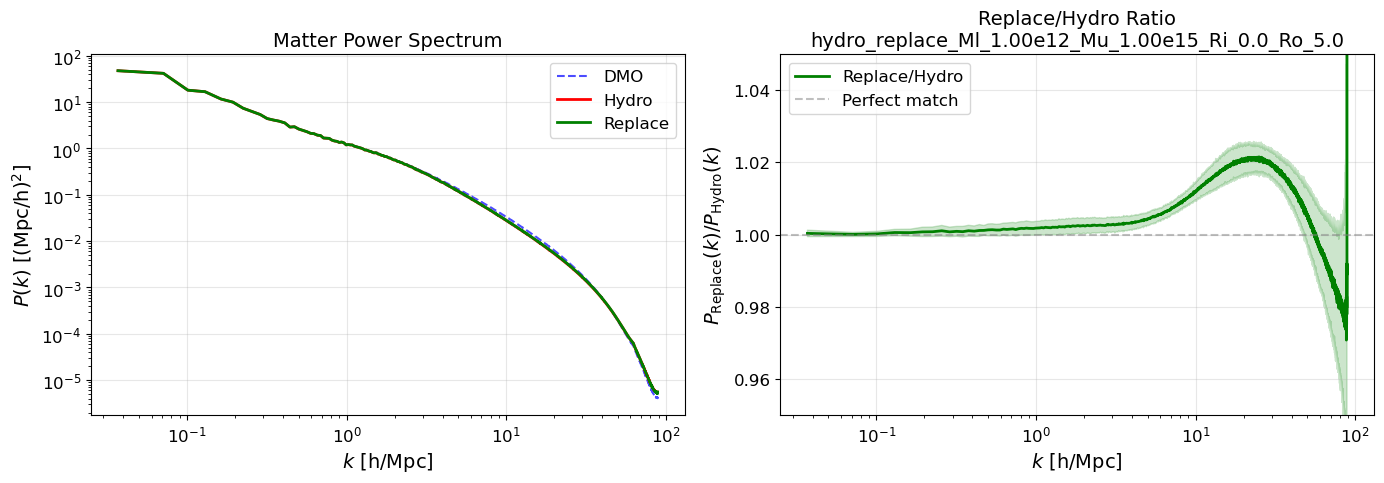

Max deviation from 1: 37843.05%


In [32]:
# P(k) comparison: Replace vs Hydro
if data_replace is not None and data_hydro is not None and 'Pk' in data_replace and 'Pk' in data_hydro:
    Pk_replace = data_replace['Pk']
    Pk_hydro = data_hydro['Pk']
    k = data_replace['k_bins']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Absolute P(k)
    ax = axes[0]
    Pk_replace_mean = np.nanmean(Pk_replace, axis=(0, 1))
    Pk_hydro_mean = np.nanmean(Pk_hydro, axis=(0, 1))
    Pk_dmo_mean = np.nanmean(data_dmo['Pk'], axis=(0, 1))
    
    ax.loglog(k, Pk_dmo_mean, 'b--', lw=1.5, alpha=0.7, label='DMO')
    ax.loglog(k, Pk_hydro_mean, 'r-', lw=2, label='Hydro')
    ax.loglog(k, Pk_replace_mean, 'g-', lw=2, label='Replace')
    ax.set_xlabel(r'$k$ [h/Mpc]')
    ax.set_ylabel(r'$P(k)$ [(Mpc/h)$^2$]')
    ax.set_title('Matter Power Spectrum')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right: Ratio Replace/Hydro
    ax = axes[1]
    # Compute ratio per LP/plane, then average (cancels cosmic variance)
    ratio_per_real = Pk_replace / Pk_hydro  # Shape: (N_LP, N_planes, N_k)
    ratio_mean = np.nanmean(ratio_per_real, axis=(0, 1))
    ratio_std = np.nanstd(ratio_per_real, axis=(0, 1))
    
    ax.semilogx(k, ratio_mean, 'g-', lw=2, label='Replace/Hydro')
    ax.fill_between(k, ratio_mean - ratio_std, ratio_mean + ratio_std, alpha=0.2, color='green')
    ax.axhline(1, color='gray', ls='--', alpha=0.5, label='Perfect match')
    ax.set_xlabel(r'$k$ [h/Mpc]')
    ax.set_ylabel(r'$P_\text{Replace}(k) / P_\text{Hydro}(k)$')
    ax.set_title(f'Replace/Hydro Ratio\n{REPLACE_MODEL}')
    ax.set_ylim(0.95, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print max deviation from 1
    max_dev = np.nanmax(np.abs(ratio_mean - 1))
    print(f"Max deviation from 1: {max_dev*100:.2f}%")
else:
    print("P(k) data not available for both models")

## Angular Power Spectrum: Replace vs Hydro

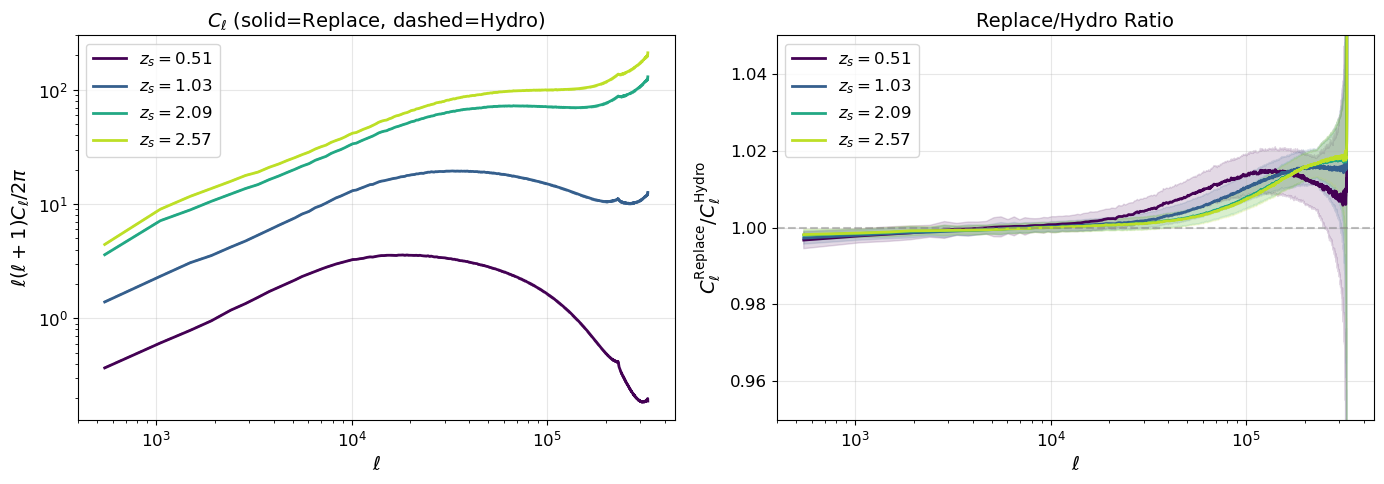

In [33]:
# C_ell comparison: Replace vs Hydro
if data_replace is not None and data_hydro is not None and 'Cl' in data_replace and 'Cl' in data_hydro:
    Cl_replace = data_replace['Cl']
    Cl_hydro = data_hydro['Cl']
    ell = data_replace['ell_bins']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute C_ell
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        Cl_hydro_mean = np.nanmean(Cl_hydro[:, z_idx, :], axis=0)
        Cl_replace_mean = np.nanmean(Cl_replace[:, z_idx, :], axis=0)
        
        ax.loglog(ell, ell * (ell + 1) * Cl_hydro_mean / (2 * np.pi), 
                  '--', color=color, lw=1.5, alpha=0.7)
        ax.loglog(ell, ell * (ell + 1) * Cl_replace_mean / (2 * np.pi), 
                  '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\ell(\ell+1)C_\ell / 2\pi$')
    ax.set_title(r'$C_\ell$ (solid=Replace, dashed=Hydro)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right: Ratio Replace/Hydro
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        ratio_per_real = Cl_replace[:, z_idx, :] / Cl_hydro[:, z_idx, :]
        ratio_mean = np.nanmean(ratio_per_real, axis=0)
        ratio_std = np.nanstd(ratio_per_real, axis=0)
        
        ax.semilogx(ell, ratio_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(ell, ratio_mean - ratio_std, ratio_mean + ratio_std, color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$C_\ell^\text{Replace} / C_\ell^\text{Hydro}$')
    ax.set_title(f'Replace/Hydro Ratio')
    ax.set_ylim(0.95, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("C_ℓ data not available for both models")

## Peak Counts: Replace vs Hydro

/tmp/ipykernel_620222/347055106.py:33: RuntimeWarning: divide by zero encountered in divide
  ratio = N_R / N_H
/tmp/ipykernel_620222/347055106.py:33: RuntimeWarning: invalid value encountered in divide
  ratio = N_R / N_H
/tmp/ipykernel_620222/347055106.py:34: RuntimeWarning: divide by zero encountered in divide
  ratio_err = ratio * np.sqrt(1.0/N_R + 1.0/N_H)
/tmp/ipykernel_620222/347055106.py:39: RuntimeWarning: invalid value encountered in subtract
  ax.fill_between(sn_centers[mask], (ratio - ratio_err)[mask], (ratio + ratio_err)[mask], color=color, alpha=0.15)


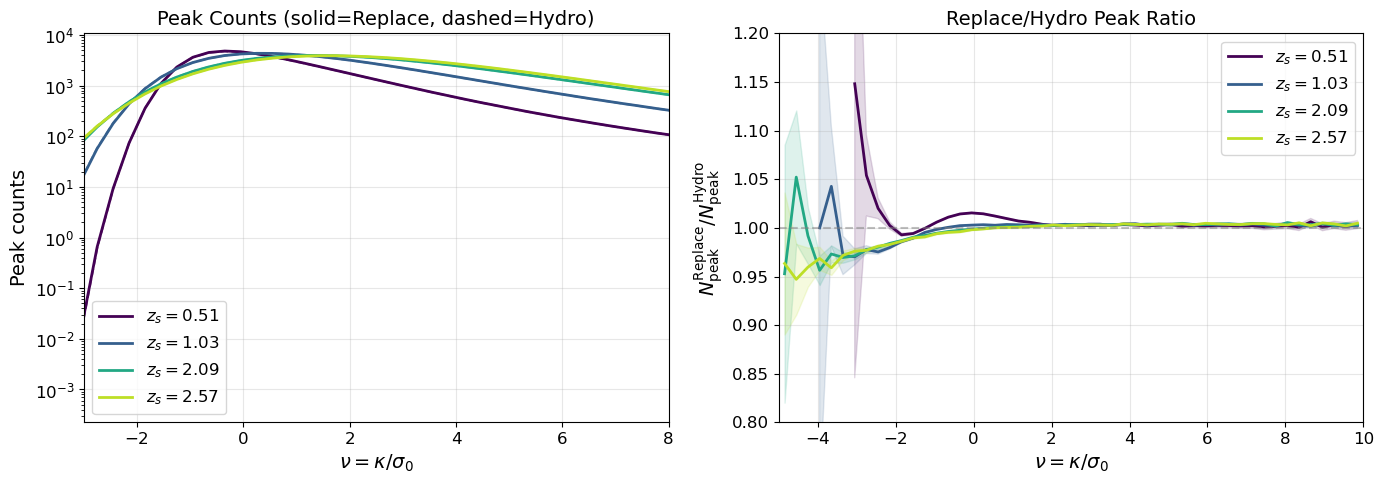

In [34]:
# Peak counts comparison: Replace vs Hydro
if data_replace is not None and data_hydro is not None and 'peaks' in data_replace and 'peaks' in data_hydro:
    peaks_replace = data_replace['peaks']
    peaks_hydro = data_hydro['peaks']
    sn_edges = data_replace['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute counts
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        peaks_hydro_mean = np.nanmean(peaks_hydro[:, z_idx, :], axis=0)
        peaks_replace_mean = np.nanmean(peaks_replace[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, peaks_hydro_mean, '--', color=color, lw=1.5, alpha=0.7)
        ax.semilogy(sn_centers, peaks_replace_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Peak counts')
    ax.set_title('Peak Counts (solid=Replace, dashed=Hydro)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-3, 8)
    
    # Right: Ratio with Poisson errors
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        N_R = np.nansum(peaks_replace[:, z_idx, :], axis=0)
        N_H = np.nansum(peaks_hydro[:, z_idx, :], axis=0)
        
        ratio = N_R / N_H
        ratio_err = ratio * np.sqrt(1.0/N_R + 1.0/N_H)
        
        mask = (N_H > 10) & (N_R > 10)
        
        ax.plot(sn_centers[mask], ratio[mask], color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers[mask], (ratio - ratio_err)[mask], (ratio + ratio_err)[mask], color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel(r'$N_\text{peak}^\text{Replace} / N_\text{peak}^\text{Hydro}$')
    ax.set_title('Replace/Hydro Peak Ratio')
    ax.set_xlim(-5, 10)
    ax.set_ylim(0.8, 1.2)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Peak counts data not available for both models")

## Minima Counts: Replace vs Hydro

/tmp/ipykernel_620222/666261611.py:33: RuntimeWarning: invalid value encountered in divide
  ratio = N_R / N_H
/tmp/ipykernel_620222/666261611.py:34: RuntimeWarning: divide by zero encountered in divide
  ratio_err = ratio * np.sqrt(1.0/N_R + 1.0/N_H)


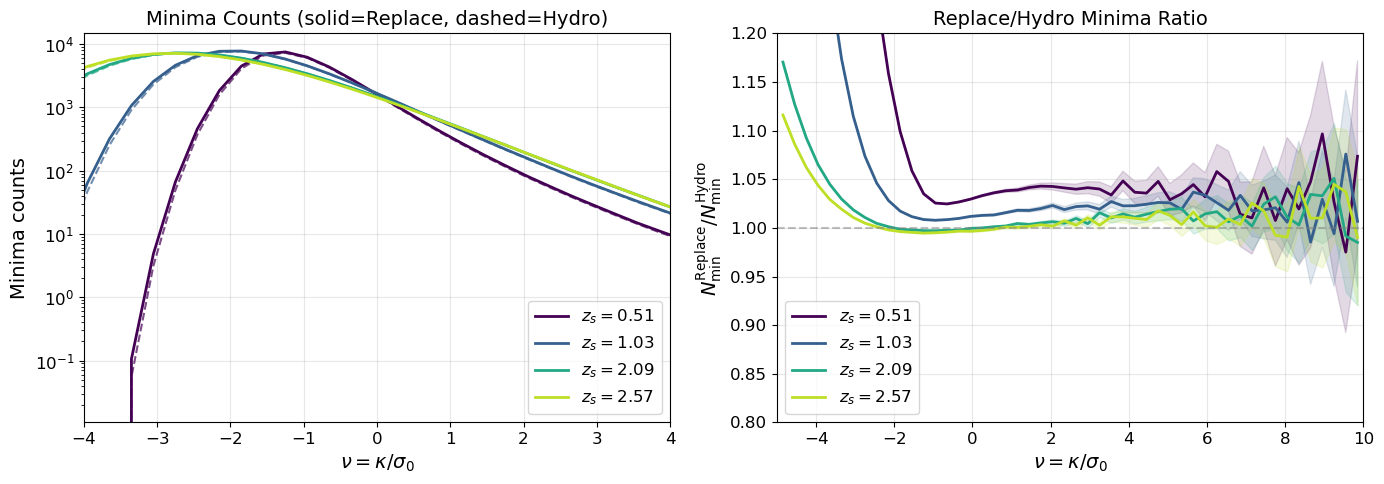

In [35]:
# Minima counts comparison: Replace vs Hydro
if data_replace is not None and data_hydro is not None and 'minima' in data_replace and 'minima' in data_hydro:
    minima_replace = data_replace['minima']
    minima_hydro = data_hydro['minima']
    sn_edges = data_replace['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute counts
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        minima_hydro_mean = np.nanmean(minima_hydro[:, z_idx, :], axis=0)
        minima_replace_mean = np.nanmean(minima_replace[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, minima_hydro_mean, '--', color=color, lw=1.5, alpha=0.7)
        ax.semilogy(sn_centers, minima_replace_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Minima counts')
    ax.set_title('Minima Counts (solid=Replace, dashed=Hydro)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 4)
    
    # Right: Ratio with Poisson errors
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        N_R = np.nansum(minima_replace[:, z_idx, :], axis=0)
        N_H = np.nansum(minima_hydro[:, z_idx, :], axis=0)
        
        ratio = N_R / N_H
        ratio_err = ratio * np.sqrt(1.0/N_R + 1.0/N_H)
        
        mask = (N_H > 10) & (N_R > 10)
        
        ax.plot(sn_centers[mask], ratio[mask], color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers[mask], (ratio - ratio_err)[mask], (ratio + ratio_err)[mask], color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel(r'$N_\text{min}^\text{Replace} / N_\text{min}^\text{Hydro}$')
    ax.set_title('Replace/Hydro Minima Ratio')
    ax.set_xlim(-5, 10)
    ax.set_ylim(0.8, 1.2)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Minima counts data not available for both models")

## PDF: Replace vs Hydro

/tmp/ipykernel_620222/746834801.py:33: RuntimeWarning: invalid value encountered in divide
  ratio = N_R / N_H
/tmp/ipykernel_620222/746834801.py:34: RuntimeWarning: divide by zero encountered in divide
  ratio_err = ratio * np.sqrt(1.0/N_R + 1.0/N_H)


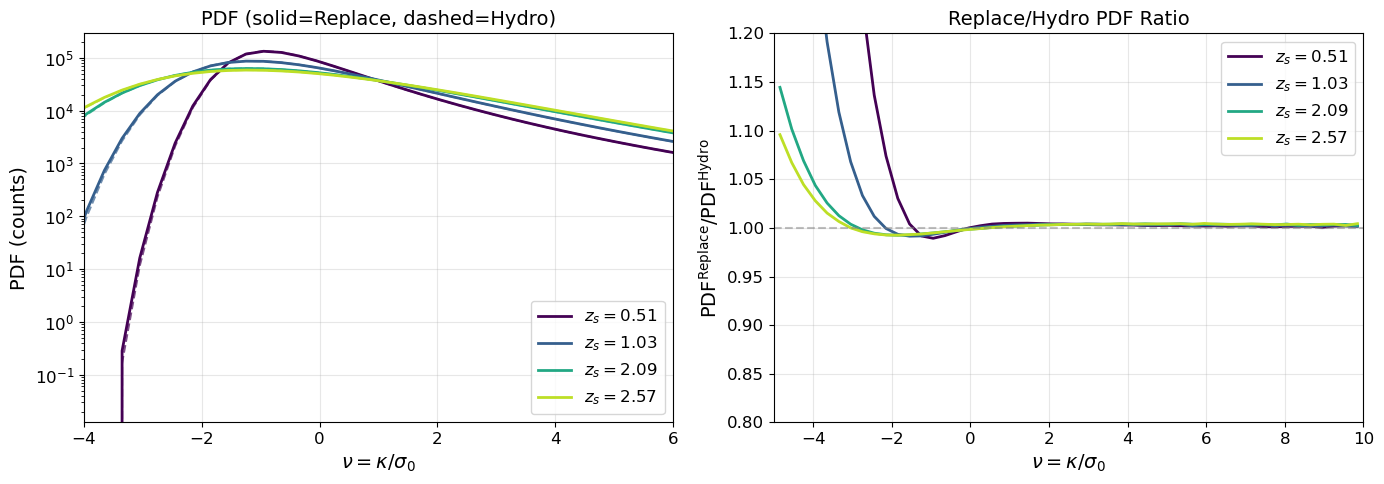

In [36]:
# PDF comparison: Replace vs Hydro
if data_replace is not None and data_hydro is not None and 'pdf' in data_replace and 'pdf' in data_hydro:
    pdf_replace = data_replace['pdf']
    pdf_hydro = data_hydro['pdf']
    sn_edges = data_replace['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute PDF
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        pdf_hydro_mean = np.nanmean(pdf_hydro[:, z_idx, :], axis=0)
        pdf_replace_mean = np.nanmean(pdf_replace[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, pdf_hydro_mean, '--', color=color, lw=1.5, alpha=0.7)
        ax.semilogy(sn_centers, pdf_replace_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('PDF (counts)')
    ax.set_title('PDF (solid=Replace, dashed=Hydro)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 6)
    
    # Right: Ratio with Poisson errors
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        N_R = np.nansum(pdf_replace[:, z_idx, :], axis=0)
        N_H = np.nansum(pdf_hydro[:, z_idx, :], axis=0)
        
        ratio = N_R / N_H
        ratio_err = ratio * np.sqrt(1.0/N_R + 1.0/N_H)
        
        mask = (N_H > 100) & (N_R > 100)
        
        ax.plot(sn_centers[mask], ratio[mask], color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers[mask], (ratio - ratio_err)[mask], (ratio + ratio_err)[mask], color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel(r'$\text{PDF}^\text{Replace} / \text{PDF}^\text{Hydro}$')
    ax.set_title('Replace/Hydro PDF Ratio')
    ax.set_xlim(-5, 10)
    ax.set_ylim(0.8, 1.2)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("PDF data not available for both models")

## Minkowski Functionals: Replace vs Hydro

/tmp/ipykernel_620222/371233639.py:44: RuntimeWarning: Mean of empty slice
  ratio_mean = np.nanmean(ratio_per_real, axis=0)


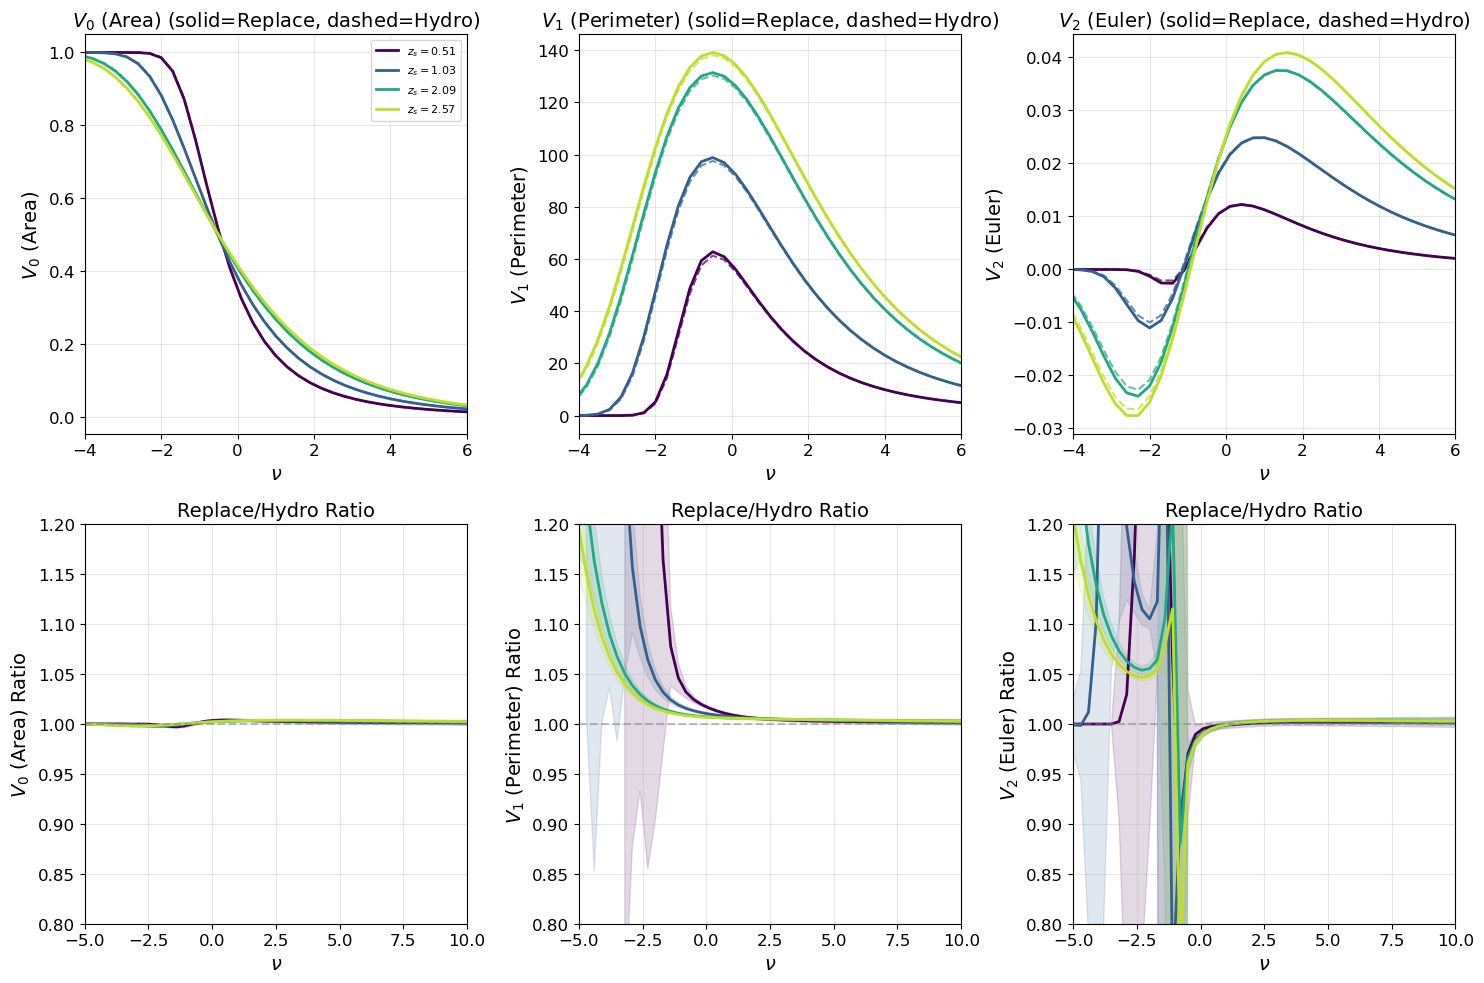

In [37]:
# Minkowski Functionals comparison: Replace vs Hydro
mf_keys = ['V0', 'V1', 'V2']
if (data_replace is not None and data_hydro is not None and 
    all(k in data_replace for k in mf_keys) and all(k in data_hydro for k in mf_keys)):
    
    nu = data_replace['mf_thresholds']
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    mf_titles = [r'$V_0$ (Area)', r'$V_1$ (Perimeter)', r'$V_2$ (Euler)']
    
    # Top row: Absolute values
    for col, (key, title) in enumerate(zip(mf_keys, mf_titles)):
        ax = axes[0, col]
        MF_replace = data_replace[key]
        MF_hydro = data_hydro[key]
        
        for z_idx, (z, color) in enumerate(zip(source_z, colors)):
            MF_hydro_mean = np.nanmean(MF_hydro[:, z_idx, :], axis=0)
            MF_replace_mean = np.nanmean(MF_replace[:, z_idx, :], axis=0)
            
            ax.plot(nu, MF_hydro_mean, '--', color=color, lw=1.5, alpha=0.7)
            ax.plot(nu, MF_replace_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
        
        ax.set_xlabel(r'$\nu$')
        ax.set_ylabel(title)
        ax.set_title(f'{title} (solid=Replace, dashed=Hydro)')
        if col == 0:
            ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-4, 6)
    
    # Bottom row: Ratios
    for col, (key, title) in enumerate(zip(mf_keys, mf_titles)):
        ax = axes[1, col]
        MF_replace = data_replace[key]
        MF_hydro = data_hydro[key]
        
        for z_idx, (z, color) in enumerate(zip(source_z, colors)):
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio_per_real = MF_replace[:, z_idx, :] / MF_hydro[:, z_idx, :]
                ratio_per_real = np.where(np.abs(MF_hydro[:, z_idx, :]) > 1e-6, ratio_per_real, np.nan)
            
            ratio_mean = np.nanmean(ratio_per_real, axis=0)
            ratio_std = np.nanstd(ratio_per_real, axis=0)
            
            ax.plot(nu, ratio_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
            ax.fill_between(nu, ratio_mean - ratio_std, ratio_mean + ratio_std, color=color, alpha=0.15)
        
        ax.axhline(1, color='gray', ls='--', alpha=0.5)
        ax.set_xlabel(r'$\nu$')
        ax.set_ylabel(f'{title} Ratio')
        ax.set_title('Replace/Hydro Ratio')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-5, 10)
        ax.set_ylim(0.8, 1.2)
    
    plt.tight_layout()
    plt.show()
else:
    print("Minkowski functionals data not available for both models")

## Wavelet Scattering Transform: Replace vs Hydro

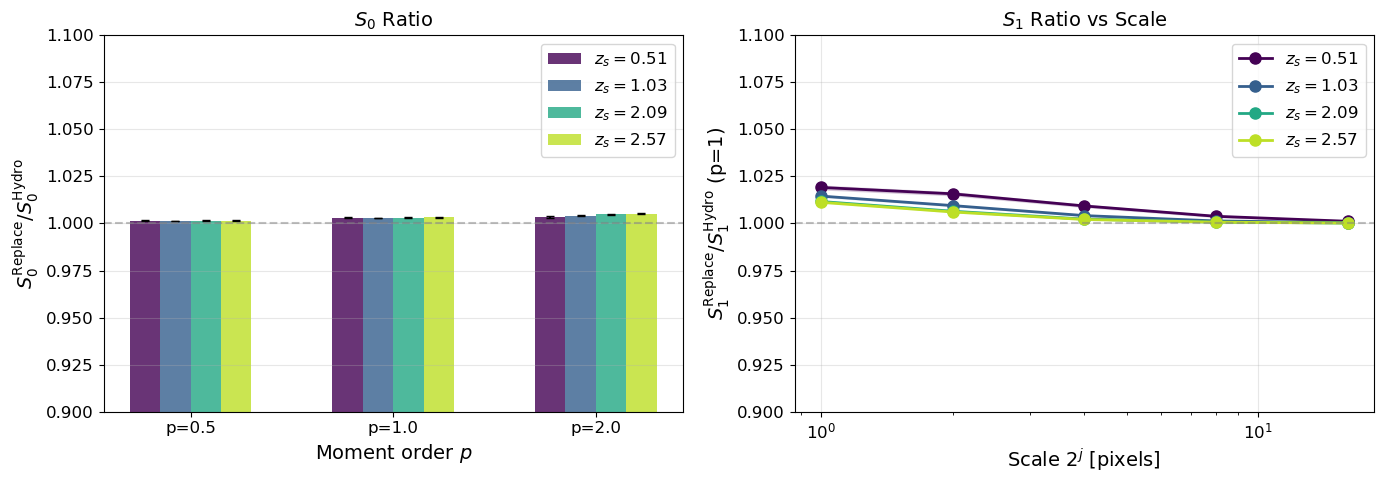

In [38]:
# WST comparison: Replace vs Hydro
if (data_replace is not None and data_hydro is not None and 
    'S0' in data_replace and 'S1' in data_replace and 'S0' in data_hydro and 'S1' in data_hydro):
    
    S0_replace = data_replace['S0']
    S0_hydro = data_hydro['S0']
    S1_replace = data_replace['S1']
    S1_hydro = data_hydro['S1']
    scales = data_replace['wst_scales']
    moments = data_replace['wst_moments']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: S0 ratio (bar chart)
    ax = axes[0]
    moment_labels = [f'p={p}' for p in moments]
    x = np.arange(len(moments))
    width = 0.15
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        S0_ratio = S0_replace[:, z_idx, :] / S0_hydro[:, z_idx, :]
        ratio_mean = np.nanmean(S0_ratio, axis=0)
        ratio_std = np.nanstd(S0_ratio, axis=0)
        
        ax.bar(x + z_idx * width, ratio_mean, width, color=color, label=f'$z_s = {z:.2f}$', alpha=0.8,
               yerr=ratio_std, capsize=3)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Moment order $p$')
    ax.set_ylabel(r'$S_0^\text{Replace} / S_0^\text{Hydro}$')
    ax.set_title(r'$S_0$ Ratio')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(moment_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.9, 1.1)
    
    # Right: S1 ratio vs scale (for p=1)
    ax = axes[1]
    p_idx = 1  # p=1.0
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        S1_ratio = S1_replace[:, z_idx, :, p_idx] / S1_hydro[:, z_idx, :, p_idx]
        ratio_mean = np.nanmean(S1_ratio, axis=0)
        ratio_std = np.nanstd(S1_ratio, axis=0)
        
        ax.semilogx(scales, ratio_mean, 'o-', color=color, lw=2, ms=8, label=f'$z_s = {z:.2f}$')
        ax.fill_between(scales, ratio_mean - ratio_std, ratio_mean + ratio_std, color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Scale $2^j$ [pixels]')
    ax.set_ylabel(r'$S_1^\text{Replace} / S_1^\text{Hydro}$ (p=1)')
    ax.set_title(r'$S_1$ Ratio vs Scale')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.9, 1.1)
    
    plt.tight_layout()
    plt.show()
else:
    print("WST data not available for both models")

## Bispectrum: Replace vs Hydro

/tmp/ipykernel_620222/3649318622.py:27: RuntimeWarning: Mean of empty slice
  ratio_mean = np.nanmean(B_ratio, axis=0)
/mnt/home/mlee1/venvs/hydro_replace/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


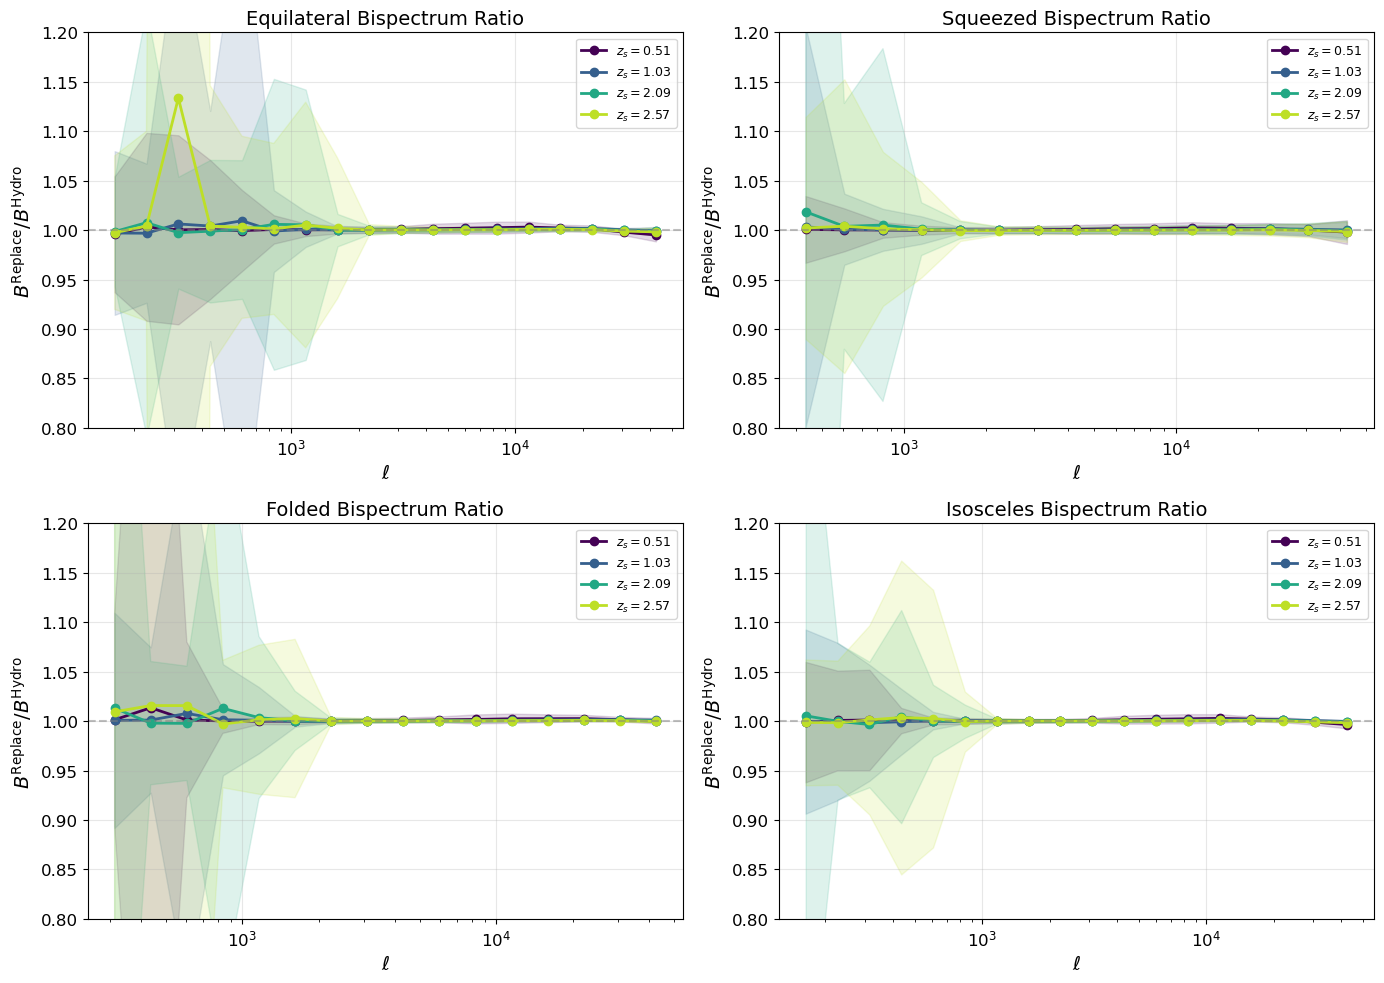

In [39]:
# Bispectrum comparison: Replace vs Hydro
bispec_keys = ['bispec_equilateral', 'bispec_squeezed', 'bispec_folded', 'bispec_isosceles']
if (data_replace is not None and data_hydro is not None and 'bispec_ell' in data_replace and
    any(k in data_replace for k in bispec_keys) and any(k in data_hydro for k in bispec_keys)):
    
    ell_bispec = data_replace['bispec_ell']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    configs = ['equilateral', 'squeezed', 'folded', 'isosceles']
    config_titles = ['Equilateral', 'Squeezed', 'Folded', 'Isosceles']
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for ax, config, title in zip(axes, configs, config_titles):
        key = f'bispec_{config}'
        if key in data_replace and key in data_hydro:
            bispec_replace = data_replace[key]
            bispec_hydro = data_hydro[key]
            
            for z_idx, (z, color) in enumerate(zip(source_z, colors)):
                with np.errstate(divide='ignore', invalid='ignore'):
                    B_ratio = bispec_replace[:, z_idx, :] / bispec_hydro[:, z_idx, :]
                    bad = (np.abs(bispec_hydro[:, z_idx, :]) < 1e-12) | (np.sign(bispec_hydro[:, z_idx, :]) != np.sign(bispec_replace[:, z_idx, :]))
                    B_ratio[bad] = np.nan
                
                ratio_mean = np.nanmean(B_ratio, axis=0)
                ratio_std = np.nanstd(B_ratio, axis=0)
                
                mask = ~np.isnan(ratio_mean)
                if np.any(mask):
                    ax.semilogx(ell_bispec[mask], ratio_mean[mask], 'o-', color=color, 
                               lw=2, ms=6, label=f'$z_s = {z:.2f}$')
                    ax.fill_between(ell_bispec[mask], (ratio_mean - ratio_std)[mask], 
                                   (ratio_mean + ratio_std)[mask], color=color, alpha=0.15)
            
            ax.axhline(1, color='gray', ls='--', alpha=0.5)
            ax.set_xlabel(r'$\ell$')
            ax.set_ylabel(r'$B^\text{Replace}/B^\text{Hydro}$')
            ax.set_title(f'{title} Bispectrum Ratio')
            ax.legend(loc='upper right', fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0.8, 1.2)
        else:
            ax.text(0.5, 0.5, f'{title} data not available', ha='center', va='center', 
                   transform=ax.transAxes)
            ax.set_title(f'{title} Bispectrum Ratio')
    
    plt.tight_layout()
    plt.show()
else:
    print("Bispectrum data not available for both models")

In [ ]:
---
# Response Analysis: F for All Statistics

This section computes the **response fraction** $F = (S_\text{Replace} - S_\text{DMO}) / (S_\text{Hydro} - S_\text{DMO})$ for each statistic, following the methodology from `density_final.ipynb`.

We will produce:
1. **Cumulative Response Heatmap**: ⟨F⟩ for all (M_min, α) combinations
2. **Scale-dependent Response**: F(x) curves for different cumulative models
3. **Tile Response Heatmap**: ΔF for discrete mass-radius tiles with marginal plots
4. **Tile Response by Mass Bin**: ΔF(x) curves organized by mass
5. **Additivity Test**: Comparing cumulative F vs sum of discrete ΔF

In [40]:
# Configuration for response analysis
import os
from scipy.ndimage import uniform_filter1d

# Model naming conventions
MASS_THRESHOLDS = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
RADII = ['0.5', '1.0', '3.0', '5.0']

# Discrete bins (exclusive models)
DISCRETE_MASS_BINS = [
    ('1.00e12', '3.16e12'),   # 10^12.0 - 10^12.5
    ('3.16e12', '1.00e13'),   # 10^12.5 - 10^13.0
    ('1.00e13', '3.16e13'),   # 10^13.0 - 10^13.5
    ('3.16e13', '1.00e15'),   # 10^13.5 - 10^15.0
]
DISCRETE_RADIUS_BINS = [
    ('0.0', '0.5'),   # Core: 0 - 0.5 R200
    ('0.5', '1.0'),   # Inner: 0.5 - 1.0 R200
    ('1.0', '3.0'),   # Middle: 1.0 - 3.0 R200
    ('3.0', '5.0'),   # Outer: 3.0 - 5.0 R200
]

# Labels for plots
MASS_LABELS = [r'$M>10^{12}$', r'$M>10^{12.5}$', r'$M>10^{13}$', r'$M>10^{13.5}$']
MASS_BIN_LABELS = [r'$[12, 12.5)$', r'$[12.5, 13)$', r'$[13, 13.5)$', r'$[13.5, \infty)$']
RADIUS_LABELS = [r'$\alpha=0.5$', r'$\alpha=1.0$', r'$\alpha=3.0$', r'$\alpha=5.0$']
RADIUS_BIN_LABELS = [r'$[0, 0.5)$', r'$[0.5, 1)$', r'$[1, 3)$', r'$[3, 5)$']

def build_cumulative_model_name(Ml, Ro):
    """Build model name for cumulative Replace model (Ri=0, Mu=1e15)"""
    return f"hydro_replace_Ml_{Ml}_Mu_1.00e15_Ri_0.0_Ro_{Ro}"

def build_discrete_model_name(Ml, Mu, Ri, Ro):
    """Build model name for discrete Replace model"""
    return f"hydro_replace_Ml_{Ml}_Mu_{Mu}_Ri_{Ri}_Ro_{Ro}"

def smooth_array(y, window=5):
    """Smooth array with uniform moving average"""
    valid = ~np.isnan(y)
    if valid.sum() < window:
        return y
    y_smooth = np.full_like(y, np.nan)
    y_smooth[valid] = uniform_filter1d(y[valid], size=window, mode='nearest')
    return y_smooth

print("Response analysis configuration loaded.")
print(f"Cumulative models: {len(MASS_THRESHOLDS)} x {len(RADII)} = {len(MASS_THRESHOLDS)*len(RADII)}")
print(f"Discrete models: {len(DISCRETE_MASS_BINS)} x {len(DISCRETE_RADIUS_BINS)} = {len(DISCRETE_MASS_BINS)*len(DISCRETE_RADIUS_BINS)}")

Response analysis configuration loaded.
Cumulative models: 4 x 4 = 16
Discrete models: 4 x 4 = 16


In [43]:
# Load all models: DMO, Hydro, all cumulative Replace, all discrete Replace
print("Loading all models...")

# Already have data_dmo and data_hydro from earlier cells
# Load cumulative models
cumulative_data = {}
for ml in MASS_THRESHOLDS:
    for ro in RADII:
        model_name = build_cumulative_model_name(ml, ro)
        try:
            data, attrs = load_model_stats(model_name)
        except:
            print(model_name)
        if data is not None:
            cumulative_data[(ml, ro)] = data
            print(f"  ✓ Cumulative {ml}, α={ro}")
        else:
            print(f"  ✗ Missing: {model_name}")

print(f"\nLoaded {len(cumulative_data)} cumulative models")

# Load discrete models
discrete_data = {}
for ml, mu in DISCRETE_MASS_BINS:
    for ri, ro in DISCRETE_RADIUS_BINS:
        model_name = build_discrete_model_name(ml, mu, ri, ro)
        try:
            data, attrs = load_model_stats(model_name)
        except:
            print(model_name)
        if data is not None:
            discrete_data[(ml, mu, ri, ro)] = data
            print(f"  ✓ Discrete M=[{ml},{mu}), r=[{ri},{ro})")
        else:
            print(f"  ✗ Missing: {model_name}")

print(f"\nLoaded {len(discrete_data)} discrete models")

Loading all models...


  ✓ Cumulative 1.00e12, α=0.5
  ✓ Cumulative 1.00e12, α=1.0
  ✓ Cumulative 1.00e12, α=3.0
  ✓ Cumulative 1.00e12, α=5.0
  ✓ Cumulative 3.16e12, α=0.5
  ✓ Cumulative 3.16e12, α=1.0
  ✓ Cumulative 3.16e12, α=3.0
  ✓ Cumulative 3.16e12, α=5.0
  ✓ Cumulative 1.00e13, α=0.5
  ✓ Cumulative 1.00e13, α=1.0
  ✓ Cumulative 1.00e13, α=3.0
  ✓ Cumulative 1.00e13, α=5.0
hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_0.5
  ✓ Cumulative 3.16e13, α=0.5
  ✓ Cumulative 3.16e13, α=1.0
  ✗ Missing: hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_3.0
  ✓ Cumulative 3.16e13, α=5.0

Loaded 15 cumulative models
  ✓ Discrete M=[1.00e12,3.16e12), r=[0.0,0.5)
  ✓ Discrete M=[1.00e12,3.16e12), r=[0.5,1.0)
  ✓ Discrete M=[1.00e12,3.16e12), r=[1.0,3.0)
  ✓ Discrete M=[1.00e12,3.16e12), r=[3.0,5.0)
  ✓ Discrete M=[3.16e12,1.00e13), r=[0.0,0.5)
  ✓ Discrete M=[3.16e12,1.00e13), r=[0.5,1.0)
  ✓ Discrete M=[3.16e12,1.00e13), r=[1.0,3.0)
  ✓ Discrete M=[3.16e12,1.00e13), r=[3.0,5.0)
  ✓ Discrete M=[1.00e13,3.16e13), r=[0.0

## Compute Response F for All Statistics

For each statistic, we compute:
- **Per-realization F**: $F_i = (S_R^i - S_D^i) / (S_H^i - S_D^i)$ for each realization
- **Mean F**: Average over realizations to cancel cosmic variance
- **Significance masking**: Only where $|S_H - S_D| > \epsilon \cdot |S_D|$

In [44]:
# Helper functions for computing response F

BARYONIC_THRESHOLD = 0.02  # 2% significance threshold

def compute_response_per_realization(S_R, S_D, S_H, threshold=BARYONIC_THRESHOLD):
    """Compute F per realization, then average.
    
    S_R, S_D, S_H: arrays of shape (N_real, ...) or (N_LP, N_planes, ...)
    Returns: F_mean, F_std over the leading dimension(s)
    """
    # Flatten to (N_real, -1) for uniform handling
    orig_shape = S_R.shape
    n_real = orig_shape[0]
    trailing_shape = orig_shape[1:]
    
    # Compute per-realization response
    Delta_S = S_H - S_D
    with np.errstate(divide='ignore', invalid='ignore'):
        # Significance mask: baryonic effect must be > threshold * DMO
        significant = np.abs(Delta_S) > threshold * np.abs(S_D)
        F_per_real = np.where(significant, (S_R - S_D) / Delta_S, np.nan)
    
    # Average over realizations (first axis)
    F_mean = np.nanmean(F_per_real, axis=0)
    F_std = np.nanstd(F_per_real, axis=0)
    
    return F_mean, F_std, F_per_real

def compute_mean_F_weighted(F_array, x_array, x_range=None, weights=None):
    """Compute weighted mean of F over x range.
    
    F_array: array of F values
    x_array: corresponding x values (k, ell, nu, etc.)
    x_range: (x_min, x_max) tuple or None for all
    weights: optional weight array (same shape as F_array)
    """
    if x_range is not None:
        mask = (x_array >= x_range[0]) & (x_array <= x_range[1])
        F_valid = F_array[mask]
        if weights is not None:
            w_valid = weights[mask]
        else:
            w_valid = None
    else:
        F_valid = F_array
        w_valid = weights
    
    valid = ~np.isnan(F_valid)
    if valid.sum() < 3:
        return np.nan
    
    if w_valid is not None:
        return np.average(F_valid[valid], weights=w_valid[valid])
    else:
        return np.nanmean(F_valid)

print("Response computation functions defined.")

Response computation functions defined.


In [45]:
# Compute F for all statistics for all cumulative models
# Focus on z_idx=1 (z_s ≈ 1.0) for convergence statistics

Z_IDX = 1  # z_s ≈ 1.0
print(f"Computing response for source redshift z_s = {source_z[Z_IDX]:.2f}")

# Get reference arrays
ell = data_dmo['ell_bins']
sn_centers = 0.5 * (data_dmo['sn_bin_edges'][:-1] + data_dmo['sn_bin_edges'][1:])
nu_mf = data_dmo['mf_thresholds']

# Store cumulative F results
cumulative_F = {
    'Cl': {},      # F_Cl(ell) for each (ml, ro)
    'peaks': {},   # F_peaks(nu) 
    'minima': {},  # F_minima(nu)
    'pdf': {},     # F_pdf(nu)
    'V0': {},      # F_V0(nu)
    'V1': {},      # F_V1(nu)
    'V2': {},      # F_V2(nu)
}

# Compute for each cumulative model
for (ml, ro), data_r in cumulative_data.items():
    key = (ml, ro)
    
    # Cl
    if 'Cl' in data_r and 'Cl' in data_dmo and 'Cl' in data_hydro:
        F_mean, F_std, _ = compute_response_per_realization(
            data_r['Cl'][:, Z_IDX, :],
            data_dmo['Cl'][:, Z_IDX, :],
            data_hydro['Cl'][:, Z_IDX, :]
        )
        cumulative_F['Cl'][key] = {'mean': F_mean, 'std': F_std, 'x': ell}
    
    # Peaks
    if 'peaks' in data_r and 'peaks' in data_dmo and 'peaks' in data_hydro:
        F_mean, F_std, _ = compute_response_per_realization(
            data_r['peaks'][:, Z_IDX, :],
            data_dmo['peaks'][:, Z_IDX, :],
            data_hydro['peaks'][:, Z_IDX, :]
        )
        cumulative_F['peaks'][key] = {'mean': F_mean, 'std': F_std, 'x': sn_centers}
    
    # Minima
    if 'minima' in data_r and 'minima' in data_dmo and 'minima' in data_hydro:
        F_mean, F_std, _ = compute_response_per_realization(
            data_r['minima'][:, Z_IDX, :],
            data_dmo['minima'][:, Z_IDX, :],
            data_hydro['minima'][:, Z_IDX, :]
        )
        cumulative_F['minima'][key] = {'mean': F_mean, 'std': F_std, 'x': sn_centers}
    
    # PDF
    if 'pdf' in data_r and 'pdf' in data_dmo and 'pdf' in data_hydro:
        F_mean, F_std, _ = compute_response_per_realization(
            data_r['pdf'][:, Z_IDX, :],
            data_dmo['pdf'][:, Z_IDX, :],
            data_hydro['pdf'][:, Z_IDX, :]
        )
        cumulative_F['pdf'][key] = {'mean': F_mean, 'std': F_std, 'x': sn_centers}
    
    # Minkowski functionals
    for mf_key in ['V0', 'V1', 'V2']:
        if mf_key in data_r and mf_key in data_dmo and mf_key in data_hydro:
            F_mean, F_std, _ = compute_response_per_realization(
                data_r[mf_key][:, Z_IDX, :],
                data_dmo[mf_key][:, Z_IDX, :],
                data_hydro[mf_key][:, Z_IDX, :]
            )
            cumulative_F[mf_key][key] = {'mean': F_mean, 'std': F_std, 'x': nu_mf}

print(f"Computed F for {len(cumulative_F['Cl'])} cumulative models")

Computing response for source redshift z_s = 1.03


/tmp/ipykernel_620222/413671772.py:24: RuntimeWarning: Mean of empty slice
  F_mean = np.nanmean(F_per_real, axis=0)
/mnt/home/mlee1/venvs/hydro_replace/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Computed F for 15 cumulative models


In [46]:
# Compute F for discrete tile models
discrete_F = {
    'Cl': {},
    'peaks': {},
    'minima': {},
    'pdf': {},
    'V0': {},
    'V1': {},
    'V2': {},
}

for (ml, mu, ri, ro), data_r in discrete_data.items():
    key = (ml, mu, ri, ro)
    
    # Cl
    if 'Cl' in data_r:
        F_mean, F_std, _ = compute_response_per_realization(
            data_r['Cl'][:, Z_IDX, :],
            data_dmo['Cl'][:, Z_IDX, :],
            data_hydro['Cl'][:, Z_IDX, :]
        )
        discrete_F['Cl'][key] = {'mean': F_mean, 'std': F_std, 'x': ell}
    
    # Peaks
    if 'peaks' in data_r:
        F_mean, F_std, _ = compute_response_per_realization(
            data_r['peaks'][:, Z_IDX, :],
            data_dmo['peaks'][:, Z_IDX, :],
            data_hydro['peaks'][:, Z_IDX, :]
        )
        discrete_F['peaks'][key] = {'mean': F_mean, 'std': F_std, 'x': sn_centers}
    
    # Minima
    if 'minima' in data_r:
        F_mean, F_std, _ = compute_response_per_realization(
            data_r['minima'][:, Z_IDX, :],
            data_dmo['minima'][:, Z_IDX, :],
            data_hydro['minima'][:, Z_IDX, :]
        )
        discrete_F['minima'][key] = {'mean': F_mean, 'std': F_std, 'x': sn_centers}
    
    # PDF
    if 'pdf' in data_r:
        F_mean, F_std, _ = compute_response_per_realization(
            data_r['pdf'][:, Z_IDX, :],
            data_dmo['pdf'][:, Z_IDX, :],
            data_hydro['pdf'][:, Z_IDX, :]
        )
        discrete_F['pdf'][key] = {'mean': F_mean, 'std': F_std, 'x': sn_centers}
    
    # Minkowski functionals
    for mf_key in ['V0', 'V1', 'V2']:
        if mf_key in data_r:
            F_mean, F_std, _ = compute_response_per_realization(
                data_r[mf_key][:, Z_IDX, :],
                data_dmo[mf_key][:, Z_IDX, :],
                data_hydro[mf_key][:, Z_IDX, :]
            )
            discrete_F[mf_key][key] = {'mean': F_mean, 'std': F_std, 'x': nu_mf}

print(f"Computed F for {len(discrete_F['Cl'])} discrete tile models")

/tmp/ipykernel_620222/413671772.py:24: RuntimeWarning: Mean of empty slice
  F_mean = np.nanmean(F_per_real, axis=0)


Computed F for 16 discrete tile models


## Figure 1: Scale-dependent Response F(x) for Each Statistic

For each statistic, show F(x) curves for different cumulative models, organized by mass threshold.

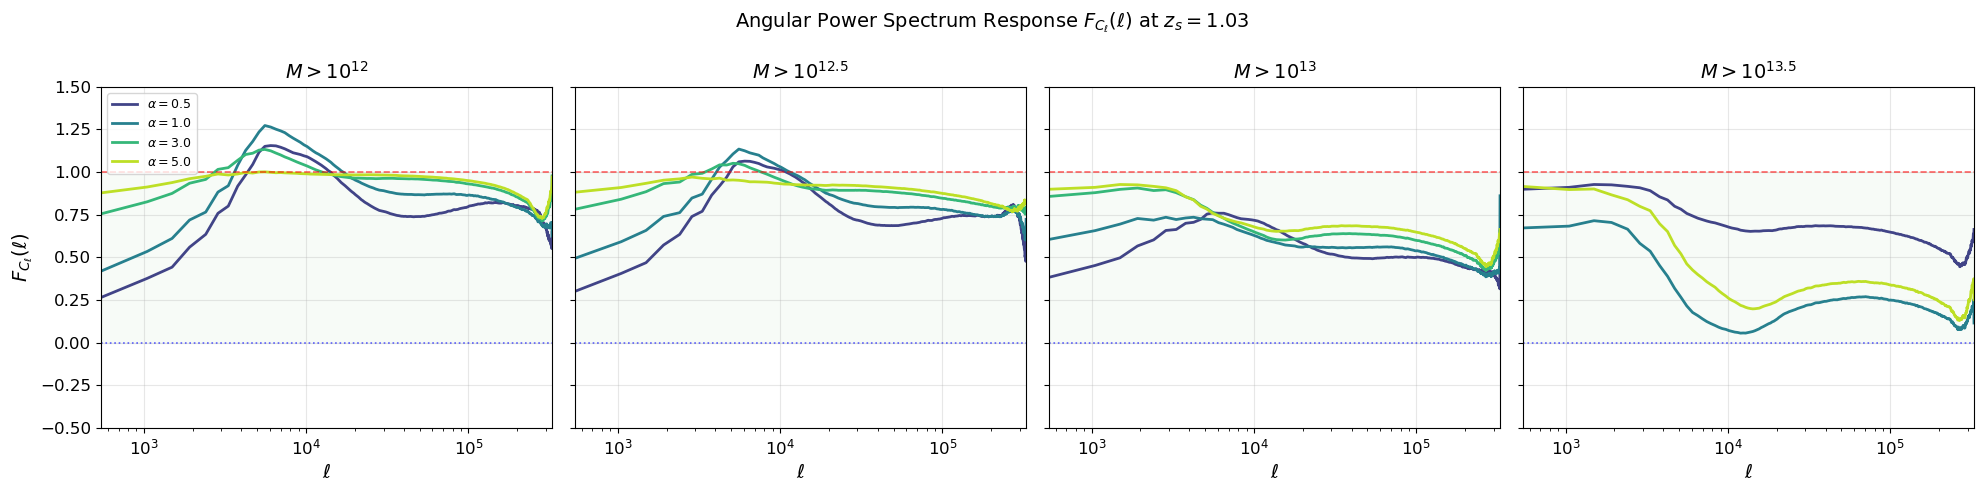

In [47]:
# Figure 1: Scale-dependent F(ℓ) for C_ℓ
# 4 panels (one per mass threshold), each with 4 lines (one per radius)

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
colors_alpha = plt.cm.viridis(np.linspace(0.2, 0.9, len(RADII)))

for ax_idx, ml in enumerate(MASS_THRESHOLDS):
    ax = axes[ax_idx]
    
    for r_idx, ro in enumerate(RADII):
        key = (ml, ro)
        if key in cumulative_F['Cl']:
            F_mean = cumulative_F['Cl'][key]['mean']
            F_smooth = smooth_array(F_mean, window=5)
            ax.semilogx(ell, F_smooth, lw=2, color=colors_alpha[r_idx], 
                       label=RADIUS_LABELS[r_idx])
    
    ax.axhline(1.0, color='red', ls='--', lw=1.2, alpha=0.6)
    ax.axhline(0.0, color='blue', ls=':', lw=1.2, alpha=0.6)
    ax.axhspan(0, 1, alpha=0.03, color='green')
    ax.set_xlim(ell.min(), ell.max())
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel(r'$\ell$')
    ax.set_title(MASS_LABELS[ax_idx])
    ax.grid(True, alpha=0.3)
    
    if ax_idx == 0:
        ax.set_ylabel(r'$F_{C_\ell}(\ell)$')
        ax.legend(loc='upper left', fontsize=9)

plt.suptitle(f'Angular Power Spectrum Response $F_{{C_\\ell}}(\\ell)$ at $z_s = {source_z[Z_IDX]:.2f}$', fontsize=14)
plt.tight_layout()
plt.savefig('figures/response_Cl_scale_dependent.png', dpi=150, bbox_inches='tight')
plt.show()

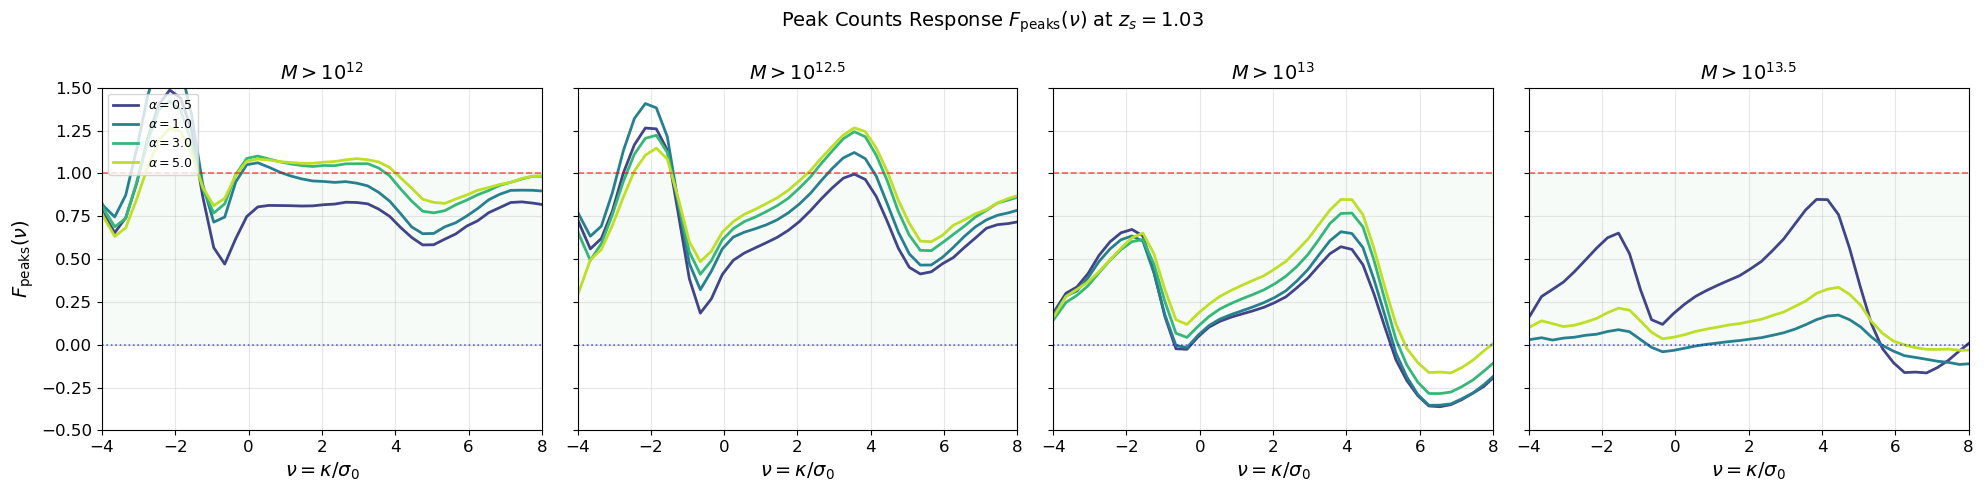

In [48]:
# Figure 2: Scale-dependent F(ν) for Peak Counts
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
colors_alpha = plt.cm.viridis(np.linspace(0.2, 0.9, len(RADII)))

for ax_idx, ml in enumerate(MASS_THRESHOLDS):
    ax = axes[ax_idx]
    
    for r_idx, ro in enumerate(RADII):
        key = (ml, ro)
        if key in cumulative_F['peaks']:
            F_mean = cumulative_F['peaks'][key]['mean']
            F_smooth = smooth_array(F_mean, window=3)
            ax.plot(sn_centers, F_smooth, lw=2, color=colors_alpha[r_idx], 
                   label=RADIUS_LABELS[r_idx])
    
    ax.axhline(1.0, color='red', ls='--', lw=1.2, alpha=0.6)
    ax.axhline(0.0, color='blue', ls=':', lw=1.2, alpha=0.6)
    ax.axhspan(0, 1, alpha=0.03, color='green')
    ax.set_xlim(-4, 8)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel(r'$\nu = \kappa/\sigma_0$')
    ax.set_title(MASS_LABELS[ax_idx])
    ax.grid(True, alpha=0.3)
    
    if ax_idx == 0:
        ax.set_ylabel(r'$F_\mathrm{peaks}(\nu)$')
        ax.legend(loc='upper left', fontsize=9)

plt.suptitle(f'Peak Counts Response $F_\\mathrm{{peaks}}(\\nu)$ at $z_s = {source_z[Z_IDX]:.2f}$', fontsize=14)
plt.tight_layout()
plt.savefig('figures/response_peaks_scale_dependent.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# Figure 3: Scale-dependent F(ν) for Minkowski Functionals (V0, V1, V2)
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey='row')
colors_alpha = plt.cm.viridis(np.linspace(0.2, 0.9, len(RADII)))

mf_keys = ['V0', 'V1', 'V2']
mf_titles = [r'$V_0$ (Area)', r'$V_1$ (Perimeter)', r'$V_2$ (Euler)']

for row, (mf_key, mf_title) in enumerate(zip(mf_keys, mf_titles)):
    for ax_idx, ml in enumerate(MASS_THRESHOLDS):
        ax = axes[row, ax_idx]
        
        for r_idx, ro in enumerate(RADII):
            key = (ml, ro)
            if key in cumulative_F[mf_key]:
                F_mean = cumulative_F[mf_key][key]['mean']
                F_smooth = smooth_array(F_mean, window=3)
                ax.plot(nu_mf, F_smooth, lw=2, color=colors_alpha[r_idx], 
                       label=RADIUS_LABELS[r_idx] if row == 0 else None)
        
        ax.axhline(1.0, color='red', ls='--', lw=1.2, alpha=0.6)
        ax.axhline(0.0, color='blue', ls=':', lw=1.2, alpha=0.6)
        ax.set_xlim(-4, 6)
        ax.set_ylim(-1, 2)
        ax.grid(True, alpha=0.3)
        
        if row == 0:
            ax.set_title(MASS_LABELS[ax_idx])
            if ax_idx == 0:
                ax.legend(loc='upper left', fontsize=8)
        if row == 2:
            ax.set_xlabel(r'$\nu$')
        if ax_idx == 0:
            ax.set_ylabel(f'$F_{{{mf_title}}}(\\nu)$')

plt.suptitle(f'Minkowski Functionals Response at $z_s = {source_z[Z_IDX]:.2f}$', fontsize=14)
plt.tight_layout()
plt.savefig('figures/response_minkowski_scale_dependent.png', dpi=150, bbox_inches='tight')
plt.show()

ValueError: 
F_{
   ^
ParseSyntaxException: Expected end_group, found end of text  (at char 3), (line:1, col:4)

Error in callback <function _draw_all_if_interactive at 0x15551d2d1580> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
F_{
   ^
ParseSyntaxException: Expected end_group, found end of text  (at char 3), (line:1, col:4)

ValueError: 
F_{
   ^
ParseSyntaxException: Expected end_group, found end of text  (at char 3), (line:1, col:4)

<Figure size 2000x1200 with 12 Axes>

## Figure 4: Cumulative Response Heatmap ⟨F⟩ for All Statistics

Compute mean response averaged over scale/threshold for each statistic and show as heatmaps.

In [51]:
# Compute mean F for each cumulative model and each statistic
# For Cl: average over ell in [1000, 50000]
# For peaks/minima/pdf: average over nu in [0, 5]
# For Minkowski: average over nu in [-2, 4]

def compute_heatmap_matrix(stat_F_dict, x_range, stat_name):
    """Compute heatmap matrix of mean F for all (M_min, α) combinations."""
    matrix = np.full((len(MASS_THRESHOLDS), len(RADII)), np.nan)
    
    for i, ml in enumerate(MASS_THRESHOLDS):
        for j, ro in enumerate(RADII):
            key = (ml, ro)
            if key in stat_F_dict:
                F_mean = stat_F_dict[key]['mean']
                x = stat_F_dict[key]['x']
                
                # Compute mean F in range
                mask = (x >= x_range[0]) & (x <= x_range[1])
                valid = mask & ~np.isnan(F_mean)
                if valid.sum() > 3:
                    matrix[i, j] = np.nanmean(F_mean[valid])
    
    return matrix

# Compute heatmap matrices for each statistic
heatmap_Cl = compute_heatmap_matrix(cumulative_F['Cl'], (1000, 50000), 'Cl')
heatmap_peaks = compute_heatmap_matrix(cumulative_F['peaks'], (0, 5), 'peaks')
heatmap_minima = compute_heatmap_matrix(cumulative_F['minima'], (-3, 2), 'minima')
heatmap_pdf = compute_heatmap_matrix(cumulative_F['pdf'], (-2, 4), 'pdf')
heatmap_V0 = compute_heatmap_matrix(cumulative_F['V0'], (-2, 4), 'V0')
heatmap_V1 = compute_heatmap_matrix(cumulative_F['V1'], (-2, 4), 'V1')
heatmap_V2 = compute_heatmap_matrix(cumulative_F['V2'], (-2, 4), 'V2')

print("Cumulative response heatmap matrices:")
print(f"  Cl: max F = {np.nanmax(heatmap_Cl):.2f}")
print(f"  peaks: max F = {np.nanmax(heatmap_peaks):.2f}")
print(f"  minima: max F = {np.nanmax(heatmap_minima):.2f}")
print(f"  pdf: max F = {np.nanmax(heatmap_pdf):.2f}")
print(f"  V0: max F = {np.nanmax(heatmap_V0):.2f}")
print(f"  V1: max F = {np.nanmax(heatmap_V1):.2f}")
print(f"  V2: max F = {np.nanmax(heatmap_V2):.2f}")

Cumulative response heatmap matrices:
  Cl: max F = 0.98
  peaks: max F = 1.04
  minima: max F = 1.03
  pdf: max F = 0.95
  V0: max F = 0.94
  V1: max F = 0.74
  V2: max F = 0.60


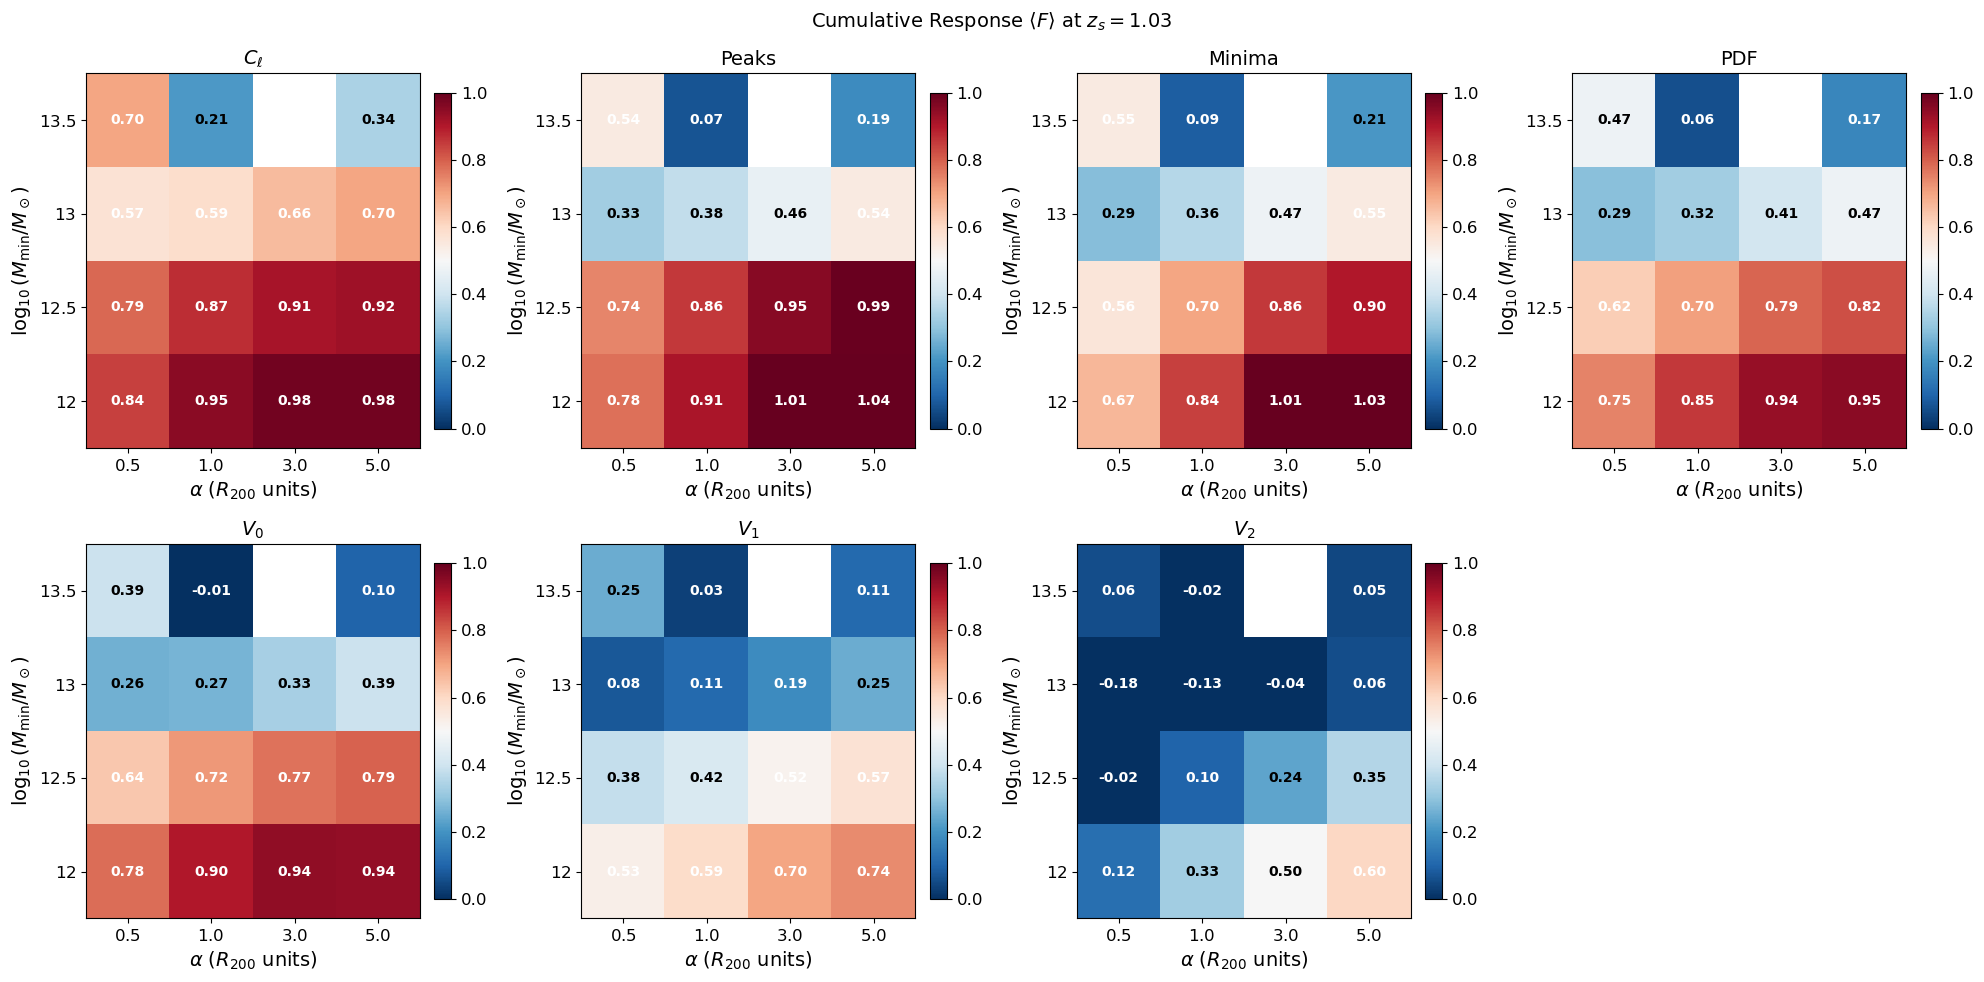

In [52]:
# Figure 4: Cumulative Response Heatmaps for all statistics
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

heatmaps = [heatmap_Cl, heatmap_peaks, heatmap_minima, heatmap_pdf, 
            heatmap_V0, heatmap_V1, heatmap_V2]
titles = [r'$C_\ell$', 'Peaks', 'Minima', 'PDF', 
          r'$V_0$', r'$V_1$', r'$V_2$']

for idx, (heatmap, title) in enumerate(zip(heatmaps, titles)):
    ax = axes.flat[idx]
    
    im = ax.imshow(heatmap, cmap='RdBu_r', aspect='auto', 
                   vmin=0, vmax=1, origin='lower')
    ax.set_xticks(range(len(RADII)))
    ax.set_xticklabels([r'$0.5$', r'$1.0$', r'$3.0$', r'$5.0$'])
    ax.set_yticks(range(len(MASS_THRESHOLDS)))
    ax.set_yticklabels([r'$12$', r'$12.5$', r'$13$', r'$13.5$'])
    ax.set_xlabel(r'$\alpha$ ($R_{200}$ units)')
    ax.set_ylabel(r'$\log_{10}(M_\mathrm{min}/M_\odot)$')
    ax.set_title(f'{title}')
    
    # Annotate with values
    for i in range(len(MASS_THRESHOLDS)):
        for j in range(len(RADII)):
            val = heatmap[i, j]
            if not np.isnan(val):
                color = 'white' if val > 0.5 or val < 0.2 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                       fontsize=10, color=color, fontweight='bold')
    
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Hide last subplot
axes.flat[-1].axis('off')

plt.suptitle(f'Cumulative Response $\\langle F \\rangle$ at $z_s = {source_z[Z_IDX]:.2f}$', fontsize=14)
plt.tight_layout()
plt.savefig('figures/response_heatmaps_all_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 5: Discrete Tile Response Heatmap with Marginals

Shows ΔF for each discrete mass-radius tile, with marginal plots showing mass and radius dependencies.

In [53]:
# Compute discrete tile ΔF heatmap matrices
def compute_tile_heatmap(stat_F_dict, x_range, stat_name):
    """Compute tile heatmap of mean ΔF for discrete models."""
    n_mass = len(DISCRETE_MASS_BINS)
    n_radius = len(DISCRETE_RADIUS_BINS)
    matrix = np.full((n_mass, n_radius), np.nan)
    
    for i, (ml, mu) in enumerate(DISCRETE_MASS_BINS):
        for j, (ri, ro) in enumerate(DISCRETE_RADIUS_BINS):
            key = (ml, mu, ri, ro)
            if key in stat_F_dict:
                F_mean = stat_F_dict[key]['mean']
                x = stat_F_dict[key]['x']
                
                mask = (x >= x_range[0]) & (x <= x_range[1])
                valid = mask & ~np.isnan(F_mean)
                if valid.sum() > 3:
                    matrix[i, j] = np.nanmean(F_mean[valid])
    
    return matrix

# Compute tile matrices
tile_Cl = compute_tile_heatmap(discrete_F['Cl'], (1000, 50000), 'Cl')
tile_peaks = compute_tile_heatmap(discrete_F['peaks'], (0, 5), 'peaks')
tile_minima = compute_tile_heatmap(discrete_F['minima'], (-3, 2), 'minima')
tile_pdf = compute_tile_heatmap(discrete_F['pdf'], (-2, 4), 'pdf')
tile_V0 = compute_tile_heatmap(discrete_F['V0'], (-2, 4), 'V0')
tile_V1 = compute_tile_heatmap(discrete_F['V1'], (-2, 4), 'V1')
tile_V2 = compute_tile_heatmap(discrete_F['V2'], (-2, 4), 'V2')

print("Tile response matrices computed.")
print(f"  Cl: sum ΔF = {np.nansum(tile_Cl):.2f}")
print(f"  peaks: sum ΔF = {np.nansum(tile_peaks):.2f}")
print(f"  minima: sum ΔF = {np.nansum(tile_minima):.2f}")
print(f"  pdf: sum ΔF = {np.nansum(tile_pdf):.2f}")

Tile response matrices computed.
  Cl: sum ΔF = 1.00
  peaks: sum ΔF = 1.42
  minima: sum ΔF = 1.38
  pdf: sum ΔF = 1.40


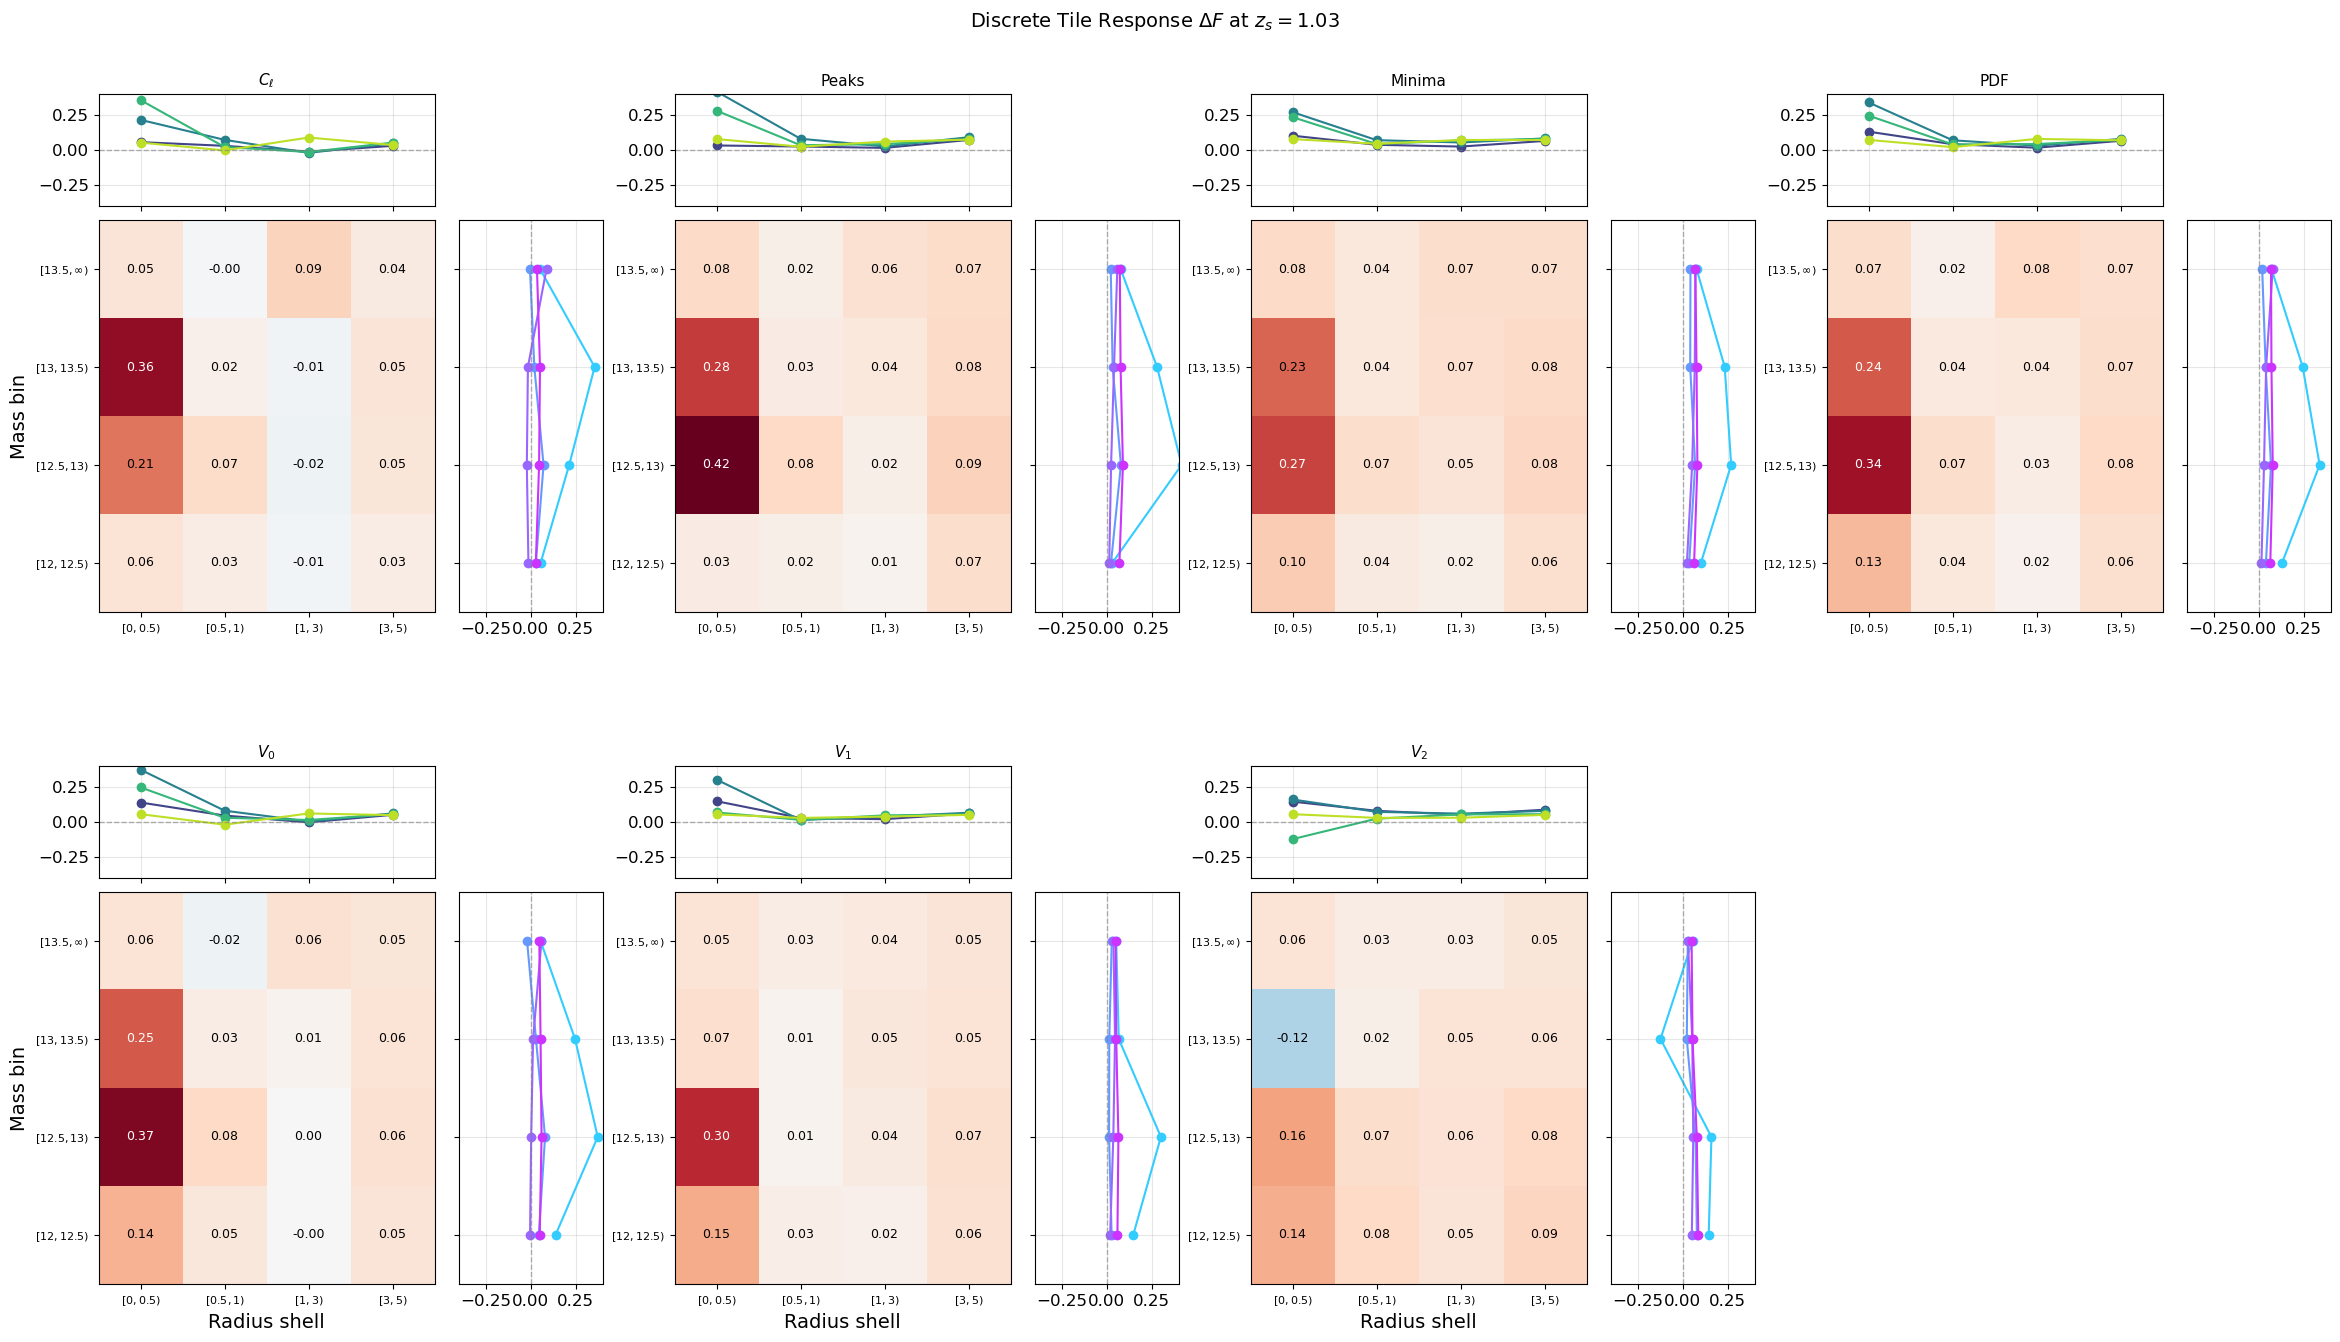

In [54]:
# Figure 5: Tile response heatmaps with marginals for all statistics
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_tile_heatmap_with_marginals(tile_matrix, stat_name, ax_main, ax_top, ax_right, vmax=0.4):
    """Plot tile heatmap with marginal line plots."""
    n_mass = len(DISCRETE_MASS_BINS)
    n_radius = len(DISCRETE_RADIUS_BINS)
    
    # Main heatmap
    im = ax_main.imshow(tile_matrix, cmap='RdBu_r', aspect='auto', 
                        vmin=-vmax, vmax=vmax, origin='lower')
    ax_main.set_xticks(range(n_radius))
    ax_main.set_xticklabels(RADIUS_BIN_LABELS, fontsize=8)
    ax_main.set_yticks(range(n_mass))
    ax_main.set_yticklabels(MASS_BIN_LABELS, fontsize=8)
    
    # Annotate with values
    for i in range(n_mass):
        for j in range(n_radius):
            val = tile_matrix[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > vmax*0.6 else 'black'
                ax_main.text(j, i, f'{val:.2f}', ha='center', va='center', 
                            fontsize=9, color=color)
    
    # Top marginal: radius response for each mass bin
    colors_mass = plt.cm.viridis(np.linspace(0.2, 0.9, n_mass))
    x_radius = np.arange(n_radius)
    for i in range(n_mass):
        ax_top.plot(x_radius, tile_matrix[i, :], 'o-', 
                    color=colors_mass[i], lw=1.5, markersize=6)
    ax_top.axhline(0, color='gray', ls='--', lw=1, alpha=0.6)
    ax_top.set_xlim(-0.5, n_radius - 0.5)
    ax_top.set_ylim(-vmax, vmax)
    plt.setp(ax_top.get_xticklabels(), visible=False)
    ax_top.grid(True, alpha=0.3)
    
    # Right marginal: mass response for each radius shell
    colors_radius = plt.cm.cool(np.linspace(0.2, 0.8, n_radius))
    y_mass = np.arange(n_mass)
    for j in range(n_radius):
        ax_right.plot(tile_matrix[:, j], y_mass, 'o-', 
                      color=colors_radius[j], lw=1.5, markersize=6)
    ax_right.axvline(0, color='gray', ls='--', lw=1, alpha=0.6)
    ax_right.set_ylim(-0.5, n_mass - 0.5)
    ax_right.set_xlim(-vmax, vmax)
    plt.setp(ax_right.get_yticklabels(), visible=False)
    ax_right.grid(True, alpha=0.3)
    
    return im

# Create figure with all statistics
fig = plt.figure(figsize=(24, 14))
tiles = [tile_Cl, tile_peaks, tile_minima, tile_pdf, tile_V0, tile_V1, tile_V2]
titles = [r'$C_\ell$', 'Peaks', 'Minima', 'PDF', r'$V_0$', r'$V_1$', r'$V_2$']

for idx, (tile_matrix, title) in enumerate(zip(tiles, titles)):
    row = idx // 4
    col = idx % 4
    
    # Create axes for this panel
    left = 0.06 + col * 0.24
    bottom = 0.55 - row * 0.48
    width = 0.14
    height = 0.28
    
    ax_main = fig.add_axes([left, bottom, width, height])
    ax_top = fig.add_axes([left, bottom + height + 0.01, width, 0.08], sharex=ax_main)
    ax_right = fig.add_axes([left + width + 0.01, bottom, 0.06, height], sharey=ax_main)
    
    im = plot_tile_heatmap_with_marginals(tile_matrix, title, ax_main, ax_top, ax_right)
    ax_top.set_title(title, fontsize=11)
    
    if col == 0:
        ax_main.set_ylabel(r'Mass bin')
    if row == 1 or idx >= 4:
        ax_main.set_xlabel(r'Radius shell')

plt.suptitle(f'Discrete Tile Response $\\Delta F$ at $z_s = {source_z[Z_IDX]:.2f}$', fontsize=14, y=0.98)
plt.savefig('figures/response_tile_heatmaps_all_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 6: Tile Response ΔF(x) by Mass Bin

Shows scale-dependent tile response organized by mass bin, with each panel showing the 4 radius shells.

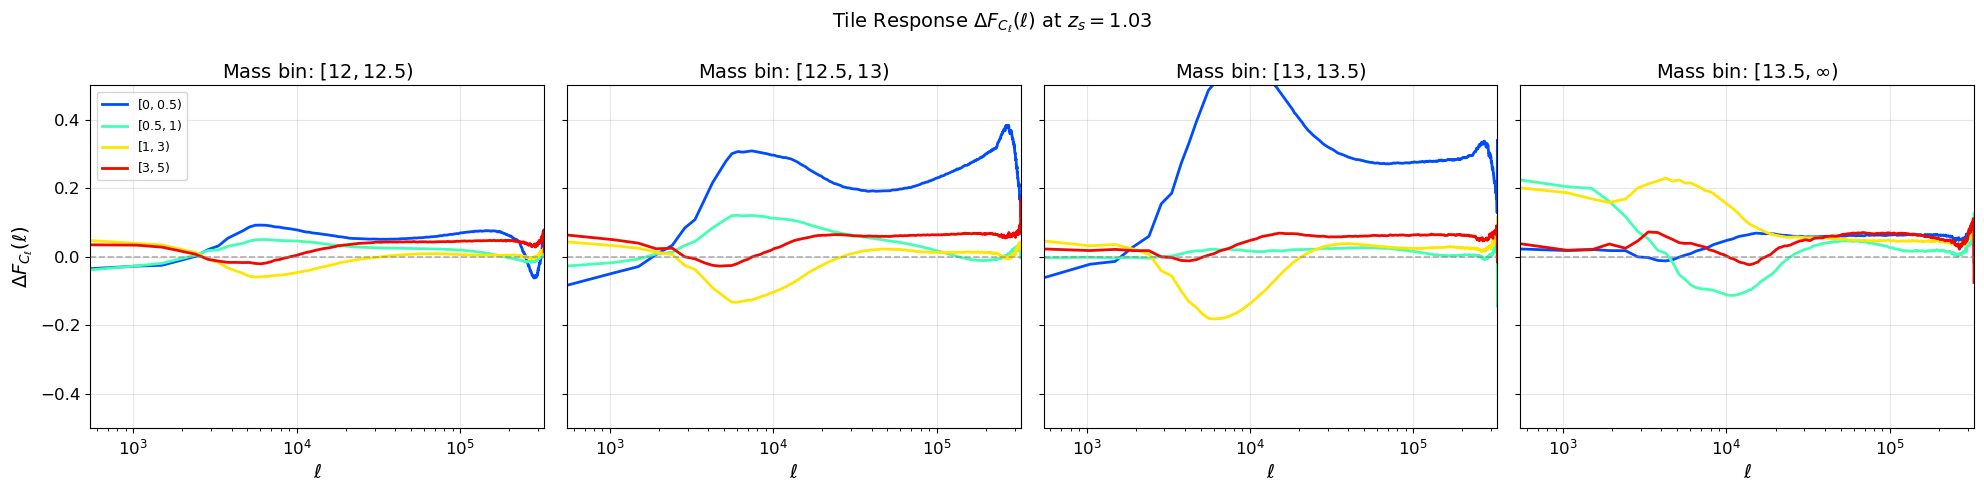

In [55]:
# Figure 6: Tile response ΔF(ℓ) for C_ℓ by mass bin
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
colors_radius = plt.cm.jet(np.linspace(0.2, 0.9, len(DISCRETE_RADIUS_BINS)))

for ax_idx, (ml, mu) in enumerate(DISCRETE_MASS_BINS):
    ax = axes[ax_idx]
    
    for r_idx, (ri, ro) in enumerate(DISCRETE_RADIUS_BINS):
        key = (ml, mu, ri, ro)
        if key in discrete_F['Cl']:
            F_mean = discrete_F['Cl'][key]['mean']
            F_smooth = smooth_array(F_mean, window=5)
            ax.semilogx(ell, F_smooth, lw=2, color=colors_radius[r_idx], 
                       label=RADIUS_BIN_LABELS[r_idx])
    
    ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.6)
    ax.set_xlim(ell.min(), ell.max())
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlabel(r'$\ell$')
    ax.set_title(f'Mass bin: {MASS_BIN_LABELS[ax_idx]}')
    ax.grid(True, alpha=0.3)
    
    if ax_idx == 0:
        ax.set_ylabel(r'$\Delta F_{C_\ell}(\ell)$')
        ax.legend(loc='upper left', fontsize=9)

plt.suptitle(f'Tile Response $\\Delta F_{{C_\\ell}}(\\ell)$ at $z_s = {source_z[Z_IDX]:.2f}$', fontsize=14)
plt.tight_layout()
plt.savefig('figures/response_tile_Cl_by_mass.png', dpi=150, bbox_inches='tight')
plt.show()

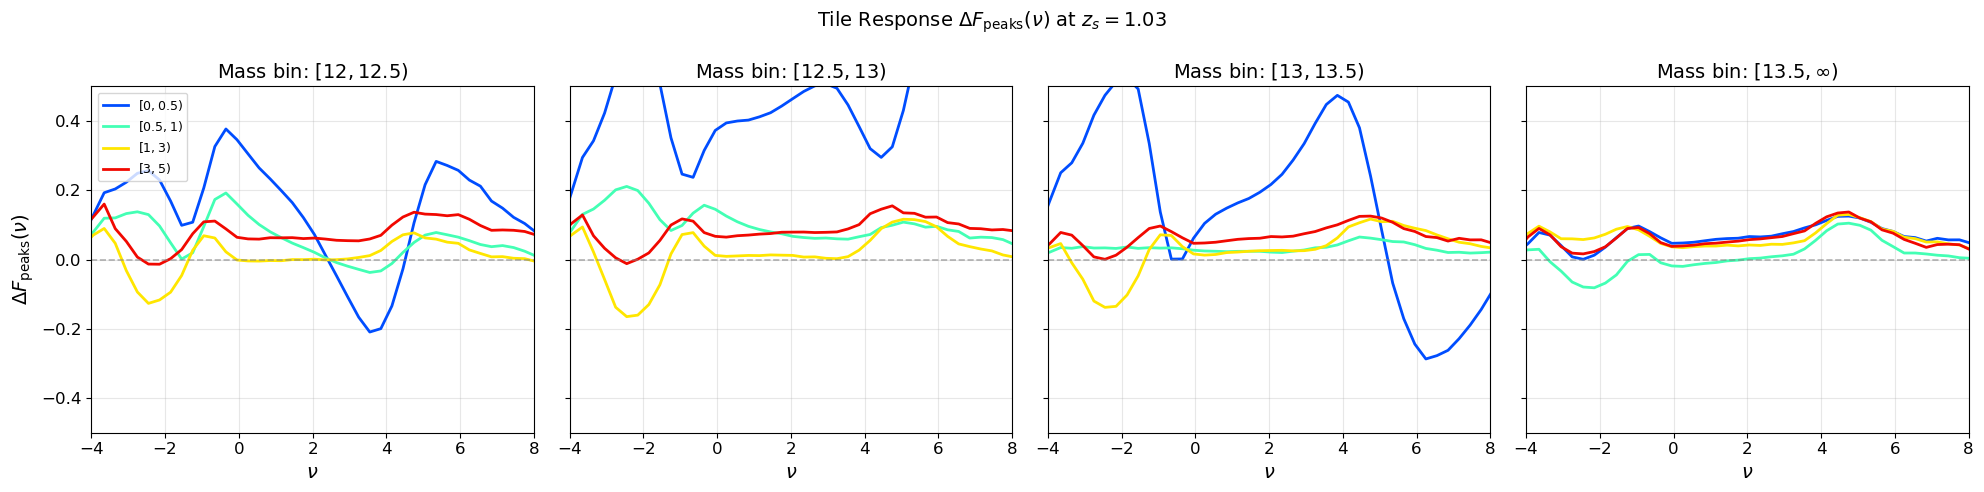

In [56]:
# Figure 6b: Tile response ΔF(ν) for Peaks by mass bin
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
colors_radius = plt.cm.jet(np.linspace(0.2, 0.9, len(DISCRETE_RADIUS_BINS)))

for ax_idx, (ml, mu) in enumerate(DISCRETE_MASS_BINS):
    ax = axes[ax_idx]
    
    for r_idx, (ri, ro) in enumerate(DISCRETE_RADIUS_BINS):
        key = (ml, mu, ri, ro)
        if key in discrete_F['peaks']:
            F_mean = discrete_F['peaks'][key]['mean']
            F_smooth = smooth_array(F_mean, window=3)
            ax.plot(sn_centers, F_smooth, lw=2, color=colors_radius[r_idx], 
                   label=RADIUS_BIN_LABELS[r_idx])
    
    ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.6)
    ax.set_xlim(-4, 8)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlabel(r'$\nu$')
    ax.set_title(f'Mass bin: {MASS_BIN_LABELS[ax_idx]}')
    ax.grid(True, alpha=0.3)
    
    if ax_idx == 0:
        ax.set_ylabel(r'$\Delta F_\mathrm{peaks}(\nu)$')
        ax.legend(loc='upper left', fontsize=9)

plt.suptitle(f'Tile Response $\\Delta F_\\mathrm{{peaks}}(\\nu)$ at $z_s = {source_z[Z_IDX]:.2f}$', fontsize=14)
plt.tight_layout()
plt.savefig('figures/response_tile_peaks_by_mass.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 7: Additivity Test

Compare cumulative F vs sum of discrete tile ΔF to test whether tiles are additive:
$$\varepsilon = F_\mathrm{cum} - \sum \Delta F_\mathrm{tiles}$$

If tiles are perfectly additive, ε ≈ 0.

In [57]:
# Compute additivity: sum of tiles vs cumulative

# Mapping from cumulative (ml, ro) to tiles that should sum to it
# Cumulative (ml, ro) includes all mass >= ml and radius < ro
# Tiles: mass bins >= ml, radius bins < ro

MASS_TO_BIN_START = {
    '1.00e12': 0,  # All mass bins
    '3.16e12': 1,  # Bins 1,2,3
    '1.00e13': 2,  # Bins 2,3
    '3.16e13': 3,  # Bin 3 only
}
RADIUS_TO_BIN_END = {
    '0.5': 1,  # Bin 0 only
    '1.0': 2,  # Bins 0,1
    '3.0': 3,  # Bins 0,1,2
    '5.0': 4,  # All radius bins
}

def compute_sum_of_tiles(stat_discrete_F, ml, ro, x_range):
    """Sum ΔF from all tiles that belong to cumulative (ml, ro)."""
    mass_start = MASS_TO_BIN_START[ml]
    radius_end = RADIUS_TO_BIN_END[ro]
    
    total_F = None
    for i, (ml_tile, mu_tile) in enumerate(DISCRETE_MASS_BINS):
        if i < mass_start:
            continue
        for j, (ri_tile, ro_tile) in enumerate(DISCRETE_RADIUS_BINS):
            if j >= radius_end:
                continue
            key = (ml_tile, mu_tile, ri_tile, ro_tile)
            if key in stat_discrete_F:
                F_mean = stat_discrete_F[key]['mean']
                if total_F is None:
                    total_F = np.zeros_like(F_mean)
                total_F = np.nansum([total_F, F_mean], axis=0)
    
    return total_F

# Compute additivity matrices for each statistic
def compute_additivity_matrix(cum_F_dict, disc_F_dict, x_range):
    """Compute ε = F_cum - Σ ΔF for all (ml, ro)."""
    n_mass = len(MASS_THRESHOLDS)
    n_radius = len(RADII)
    
    F_cum_matrix = np.full((n_mass, n_radius), np.nan)
    sum_tiles_matrix = np.full((n_mass, n_radius), np.nan)
    epsilon_matrix = np.full((n_mass, n_radius), np.nan)
    
    for i, ml in enumerate(MASS_THRESHOLDS):
        for j, ro in enumerate(RADII):
            key = (ml, ro)
            
            # Cumulative F
            if key in cum_F_dict:
                F_mean = cum_F_dict[key]['mean']
                x = cum_F_dict[key]['x']
                mask = (x >= x_range[0]) & (x <= x_range[1])
                valid = mask & ~np.isnan(F_mean)
                if valid.sum() > 3:
                    F_cum_matrix[i, j] = np.nanmean(F_mean[valid])
            
            # Sum of tiles
            sum_F = compute_sum_of_tiles(disc_F_dict, ml, ro, x_range)
            if sum_F is not None:
                x = list(disc_F_dict.values())[0]['x']
                mask = (x >= x_range[0]) & (x <= x_range[1])
                valid = mask & ~np.isnan(sum_F)
                if valid.sum() > 3:
                    sum_tiles_matrix[i, j] = np.nanmean(sum_F[valid])
            
            # Epsilon
            if not np.isnan(F_cum_matrix[i, j]) and not np.isnan(sum_tiles_matrix[i, j]):
                epsilon_matrix[i, j] = F_cum_matrix[i, j] - sum_tiles_matrix[i, j]
    
    return F_cum_matrix, sum_tiles_matrix, epsilon_matrix

# Compute for all statistics
additivity_results = {}
for stat_name, x_range in [('Cl', (1000, 50000)), ('peaks', (0, 5)), 
                            ('minima', (-3, 2)), ('pdf', (-2, 4)),
                            ('V0', (-2, 4)), ('V1', (-2, 4)), ('V2', (-2, 4))]:
    if cumulative_F[stat_name] and discrete_F[stat_name]:
        F_cum, sum_tiles, epsilon = compute_additivity_matrix(
            cumulative_F[stat_name], discrete_F[stat_name], x_range
        )
        additivity_results[stat_name] = {
            'F_cum': F_cum,
            'sum_tiles': sum_tiles,
            'epsilon': epsilon
        }

print("Additivity computed for all statistics.")

Additivity computed for all statistics.


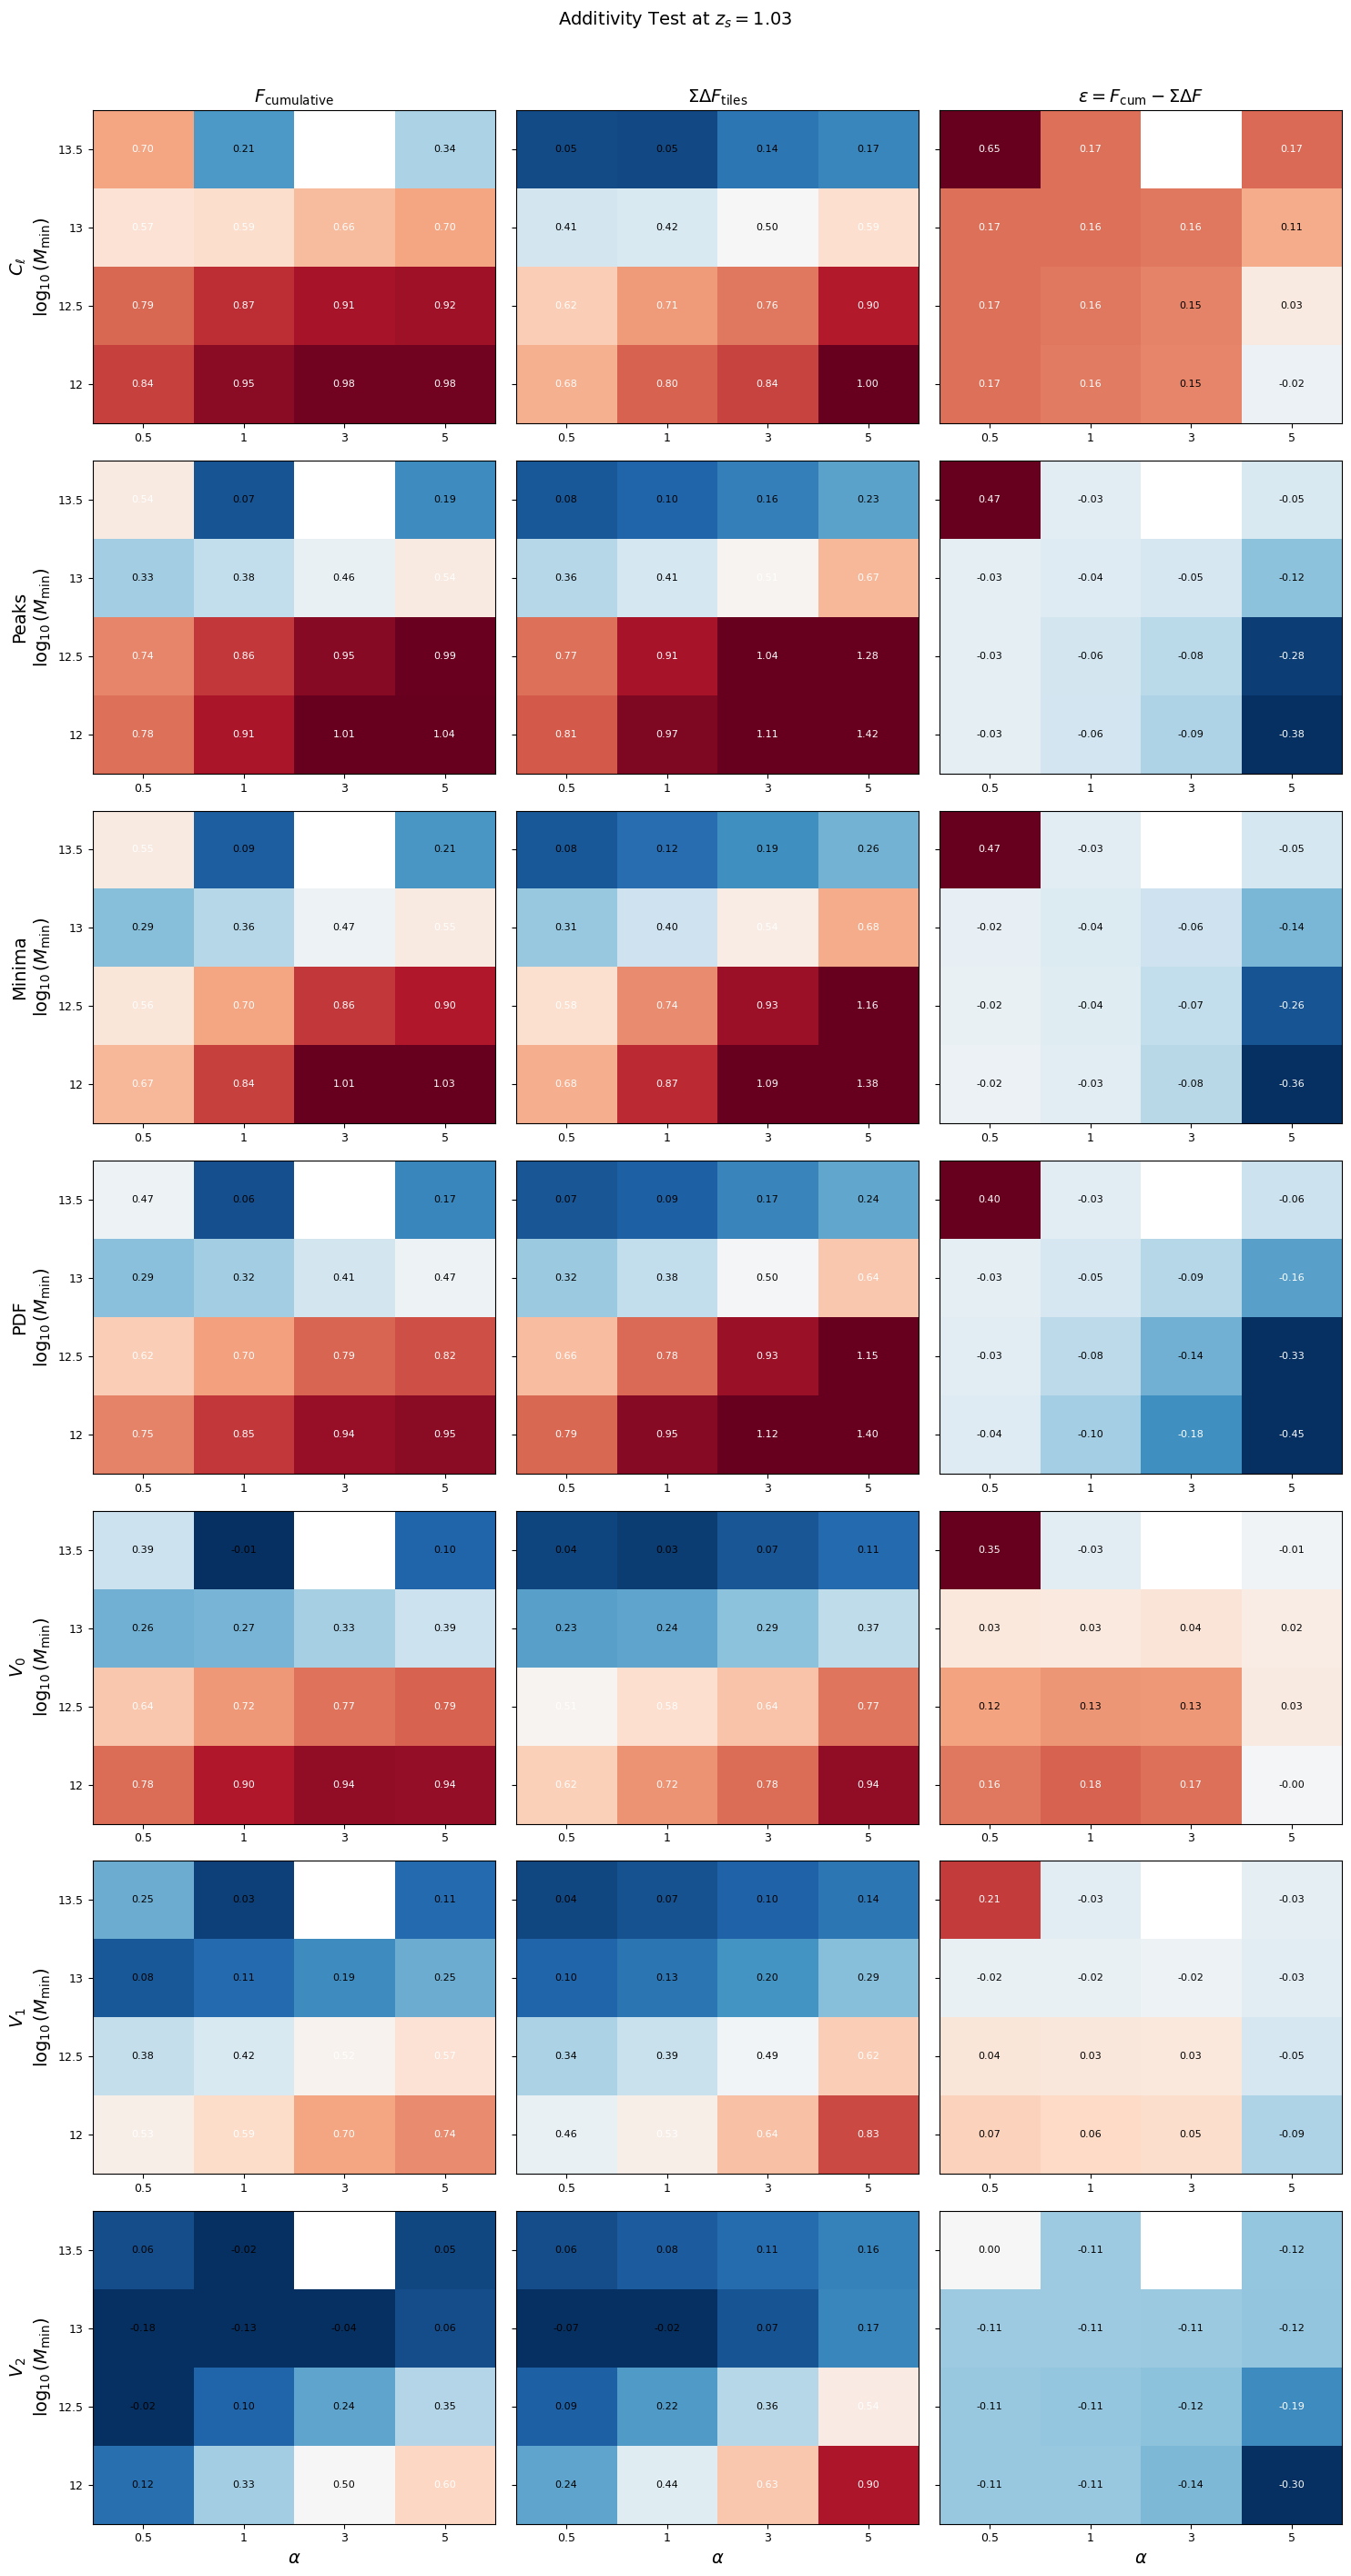


ADDITIVITY TEST SUMMARY
$C_\ell$     | Mean |ε| = 0.171, Max |ε| = 0.645
Peaks        | Mean |ε| = 0.120, Max |ε| = 0.465
Minima       | Mean |ε| = 0.114, Max |ε| = 0.469
PDF          | Mean |ε| = 0.146, Max |ε| = 0.453
$V_0$        | Mean |ε| = 0.095, Max |ε| = 0.352
$V_1$        | Mean |ε| = 0.053, Max |ε| = 0.209
$V_2$        | Mean |ε| = 0.125, Max |ε| = 0.301


In [58]:
# Figure 7: Additivity test - 3 columns per statistic: F_cum, Σ ΔF, ε
fig, axes = plt.subplots(len(additivity_results), 3, figsize=(15, 4*len(additivity_results)))

stat_names = list(additivity_results.keys())
stat_titles = [r'$C_\ell$', 'Peaks', 'Minima', 'PDF', r'$V_0$', r'$V_1$', r'$V_2$']

for row, (stat_name, stat_title) in enumerate(zip(stat_names, stat_titles)):
    res = additivity_results[stat_name]
    
    # Column 0: F_cum
    ax = axes[row, 0]
    im = ax.imshow(res['F_cum'], cmap='RdBu_r', aspect='auto', vmin=0, vmax=1, origin='lower')
    ax.set_xticks(range(len(RADII)))
    ax.set_xticklabels([r'$0.5$', r'$1$', r'$3$', r'$5$'], fontsize=9)
    ax.set_yticks(range(len(MASS_THRESHOLDS)))
    ax.set_yticklabels([r'$12$', r'$12.5$', r'$13$', r'$13.5$'], fontsize=9)
    for i in range(len(MASS_THRESHOLDS)):
        for j in range(len(RADII)):
            val = res['F_cum'][i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                       color='white' if val > 0.5 else 'black')
    ax.set_ylabel(f'{stat_title}\n' + r'$\log_{10}(M_\mathrm{min})$')
    if row == 0:
        ax.set_title(r'$F_\mathrm{cumulative}$')
    if row == len(stat_names) - 1:
        ax.set_xlabel(r'$\alpha$')
    
    # Column 1: Sum of tiles
    ax = axes[row, 1]
    im = ax.imshow(res['sum_tiles'], cmap='RdBu_r', aspect='auto', vmin=0, vmax=1, origin='lower')
    ax.set_xticks(range(len(RADII)))
    ax.set_xticklabels([r'$0.5$', r'$1$', r'$3$', r'$5$'], fontsize=9)
    ax.set_yticks(range(len(MASS_THRESHOLDS)))
    ax.set_yticklabels([])
    for i in range(len(MASS_THRESHOLDS)):
        for j in range(len(RADII)):
            val = res['sum_tiles'][i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                       color='white' if val > 0.5 else 'black')
    if row == 0:
        ax.set_title(r'$\Sigma \Delta F_\mathrm{tiles}$')
    if row == len(stat_names) - 1:
        ax.set_xlabel(r'$\alpha$')
    
    # Column 2: Epsilon (non-additivity)
    ax = axes[row, 2]
    im = ax.imshow(res['epsilon'], cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3, origin='lower')
    ax.set_xticks(range(len(RADII)))
    ax.set_xticklabels([r'$0.5$', r'$1$', r'$3$', r'$5$'], fontsize=9)
    ax.set_yticks(range(len(MASS_THRESHOLDS)))
    ax.set_yticklabels([])
    for i in range(len(MASS_THRESHOLDS)):
        for j in range(len(RADII)):
            val = res['epsilon'][i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                       color='white' if abs(val) > 0.15 else 'black')
    if row == 0:
        ax.set_title(r'$\varepsilon = F_\mathrm{cum} - \Sigma \Delta F$')
    if row == len(stat_names) - 1:
        ax.set_xlabel(r'$\alpha$')

plt.suptitle(f'Additivity Test at $z_s = {source_z[Z_IDX]:.2f}$', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/response_additivity_all_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*60)
print("ADDITIVITY TEST SUMMARY")
print("="*60)
for stat_name, stat_title in zip(stat_names, stat_titles):
    eps = additivity_results[stat_name]['epsilon']
    print(f"{stat_title:12} | Mean |ε| = {np.nanmean(np.abs(eps)):.3f}, Max |ε| = {np.nanmax(np.abs(eps)):.3f}")